In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacalv3 as cacalv3

importlib.reload(cacalv3)
from dynamics.cacalv3 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_ppc import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics

# =============================================================================
# 全局配置（所有功能都可以开关）
# =============================================================================
RUN_CFG = {
    "seed": 2026,
    "enable_koopman_training": True,
    "enable_koopman_linear_refit": True,
    "enable_four_vehicle": True,
    "enable_curved_tracking": True,
    "enable_adaptive_weight_matrix": True,
    "enable_ppc_soft_constraints": True,
    "enable_dynamic_ppc": True,
    "enable_cooperative_transport": True,
    "enable_solver_guard": True,
}

KOOPMAN_CFG = {
    "encoder_hidden_width": 96,
    "encoder_hidden_depth": 4,
    "encoder_output_dim": 20,
    "lr": 3e-4,
    "epochs": 140,
    "batch_size": 4096,
    "weight_decay": 8e-5,
    "ridge_lambda": 5e-5,
    "linear_fit_blend": 0.60,
    "previous_model_blend": 0.20,
    "deterministic_training": True,
}

MPC_CFG = {
    "path_length": 100.0,
    "horizon": 45,
    "max_sqp_iters": 3,
    "ff_gain": 0.75,
    "delta_alpha": 0.60,
    "ax_alpha": 0.50,
    "weight_smoothing": 0.80,
    "weight_rate_limit": 0.22,
    "osqp_time_limit": 0.035,
}

PPC_CFG = {
    "rho_ey_0": 0.45,
    "rho_ey_inf": 0.035,
    "lambda_ey": 1.25,
    "rho_epsi_0": 0.22,
    "rho_epsi_inf": 0.025,
    "lambda_epsi": 1.35,
    "curvature_gain": 0.45,
    "curvature_norm": 0.060,
}

FORMATION_CFG = {
    "leader_index": 0,
    "k_s": 0.08,
    "k_vx": 0.10,
    "k_ey": 0.65,
    "k_epsi": 0.25,
}


def set_global_seed(seed, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = bool(deterministic)
    torch.backends.cudnn.benchmark = not bool(deterministic)
    torch.use_deterministic_algorithms(bool(deterministic), warn_only=True)


set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
print("功能开关:", RUN_CFG)


Using device: cuda
GPU: NVIDIA GeForce RTX 5080
功能开关: {'seed': 2026, 'enable_koopman_training': True, 'enable_koopman_linear_refit': True, 'enable_four_vehicle': True, 'enable_curved_tracking': True, 'enable_adaptive_weight_matrix': True, 'enable_ppc_soft_constraints': True, 'enable_dynamic_ppc': True, 'enable_cooperative_transport': True, 'enable_solver_guard': True}


In [2]:

# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


def clip_closed_loop_state(x, s_upper=500.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], 0.0, s_upper)  # s
    x[1] = np.clip(x[1], -5.0, 5.0)  # e_y
    x[2] = np.clip(x[2], -1.2, 1.2)  # e_psi
    x[3] = np.clip(x[3], 0.5, 8.0)  # v_x
    x[4] = np.clip(x[4], -4.0, 4.0)  # v_y
    x[5] = np.clip(x[5], -3.0, 3.0)  # r
    return x


def is_finite_vector(x):
    x = np.asarray(x, dtype=float)
    return np.all(np.isfinite(x))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    """
    对 FK_solver 做保护：
    - 若求解结果非有限，则回退到 fallback_state 或当前状态
    - 输出统一做 clip
    """
    try:
        x_next = FK_solver(
            x, u, pars,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=i
        )
    except Exception as e:
        if verbose:
            print(f"FK_solver exception at step {i}: {e}")
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    if not is_finite_vector(x_next):
        if verbose:
            print(f"Non-finite FK_solver output at step {i}")
            print("x =", x)
            print("u =", u)
            print("x_next =", x_next)
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    return clip_closed_loop_state(x_next)


# ===== Koopman 线性重拟合（可开关） =====
def _lift_batch_with_net(net, x_scaled, batch_size=8192):
    z_chunks = []
    net.eval()
    with torch.no_grad():
        for i in range(0, x_scaled.shape[0], batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size]).float().to(net.device)
            zb = net.lift(xb).detach().cpu().numpy()
            z_chunks.append(zb)
    return np.vstack(z_chunks)


def fit_koopman_linear_matrices(model, xs_data, us_data, ridge_lambda=1e-5, batch_size=8192):
    if xs_data is None or us_data is None:
        raise ValueError("fit_koopman_linear_matrices requires xs_data and us_data")

    net = model.net
    t_eff = min(xs_data.shape[1] - 1, us_data.shape[1])

    x_curr = xs_data[:, :t_eff, :].reshape(-1, xs_data.shape[2])
    x_next = xs_data[:, 1:t_eff + 1, :].reshape(-1, xs_data.shape[2])
    u_curr = us_data[:, :t_eff, :].reshape(-1, us_data.shape[2])

    if net.standardizer_x is not None:
        x_curr_scaled = net.standardizer_x.transform(x_curr)
        x_next_scaled = net.standardizer_x.transform(x_next)
    else:
        x_curr_scaled = x_curr
        x_next_scaled = x_next

    if net.standardizer_u is not None:
        u_curr_scaled = net.standardizer_u.transform(u_curr)
    else:
        u_curr_scaled = u_curr

    z_curr = _lift_batch_with_net(net, x_curr_scaled.astype(np.float32), batch_size=batch_size)
    z_next = _lift_batch_with_net(net, x_next_scaled.astype(np.float32), batch_size=batch_size)

    phi = np.hstack([z_curr, u_curr_scaled]).astype(np.float64)
    z_next64 = z_next.astype(np.float64)

    eye = np.eye(phi.shape[1], dtype=np.float64)
    theta = np.linalg.solve(phi.T @ phi + ridge_lambda * eye, phi.T @ z_next64)

    nz = z_curr.shape[1]
    A_fit = theta[:nz, :].T
    B_fit = theta[nz:, :].T

    if getattr(net, "first_obs_const", False):
        A_fit[0, :] = 0.0
        A_fit[0, 0] = 1.0
        B_fit[0, :] = 0.0

    z_pred = phi @ theta
    rmse = float(np.sqrt(np.mean((z_pred - z_next64) ** 2)))
    return A_fit.astype(np.float32), B_fit.astype(np.float32), {"lifted_rmse": rmse, "samples": int(phi.shape[0])}


def blend_matrix(base_mat, new_mat, blend_ratio):
    beta = float(np.clip(blend_ratio, 0.0, 1.0))
    return ((1.0 - beta) * base_mat + beta * new_mat).astype(np.float32)


def summarize_solver_status(status_list):
    if not status_list:
        return {}
    values, counts = np.unique(np.array(status_list, dtype=object), return_counts=True)
    return {str(v): int(c) for v, c in zip(values, counts)}


正在生成覆盖双移线边界条件的多场景数据...
X shape: (400, 500, 6)
X_changed shape: (400, 500, 6)
U shape: (400, 499, 2)
离线数据已保存。


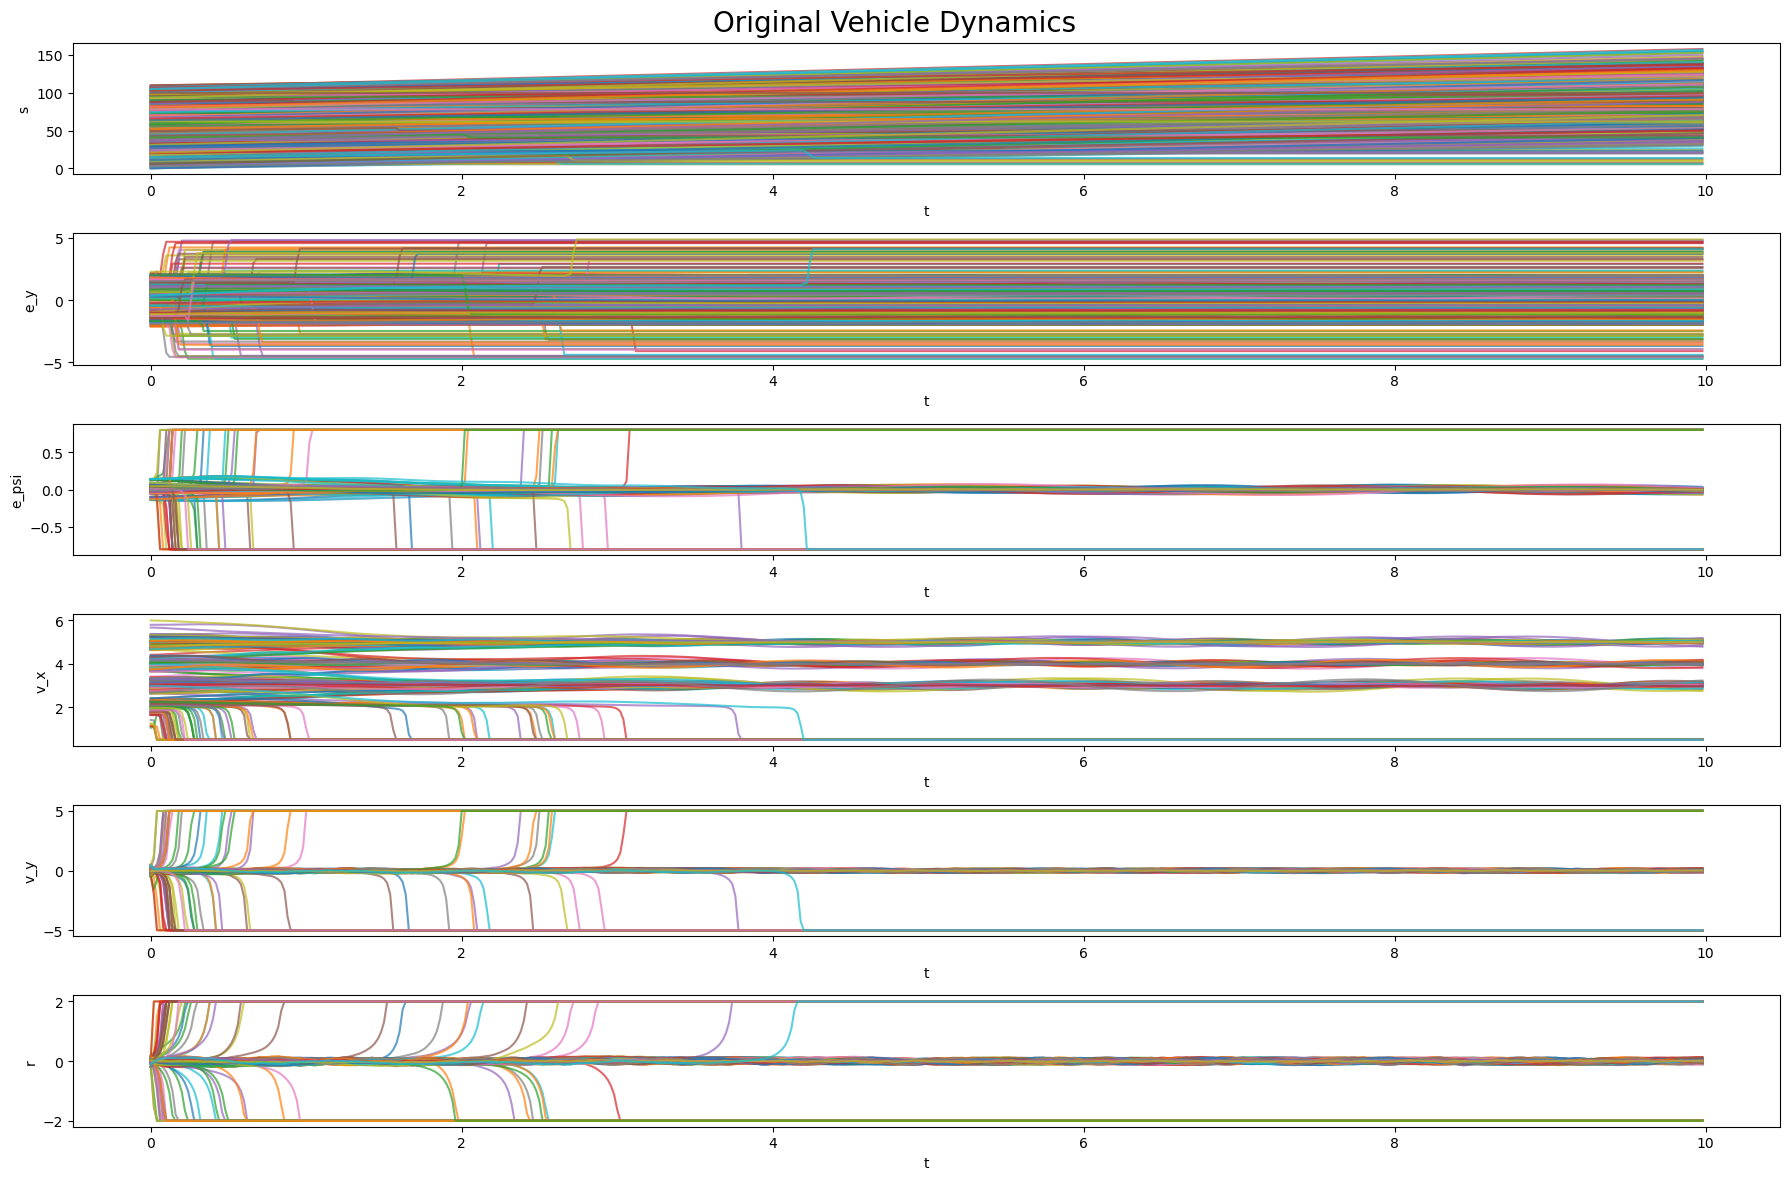

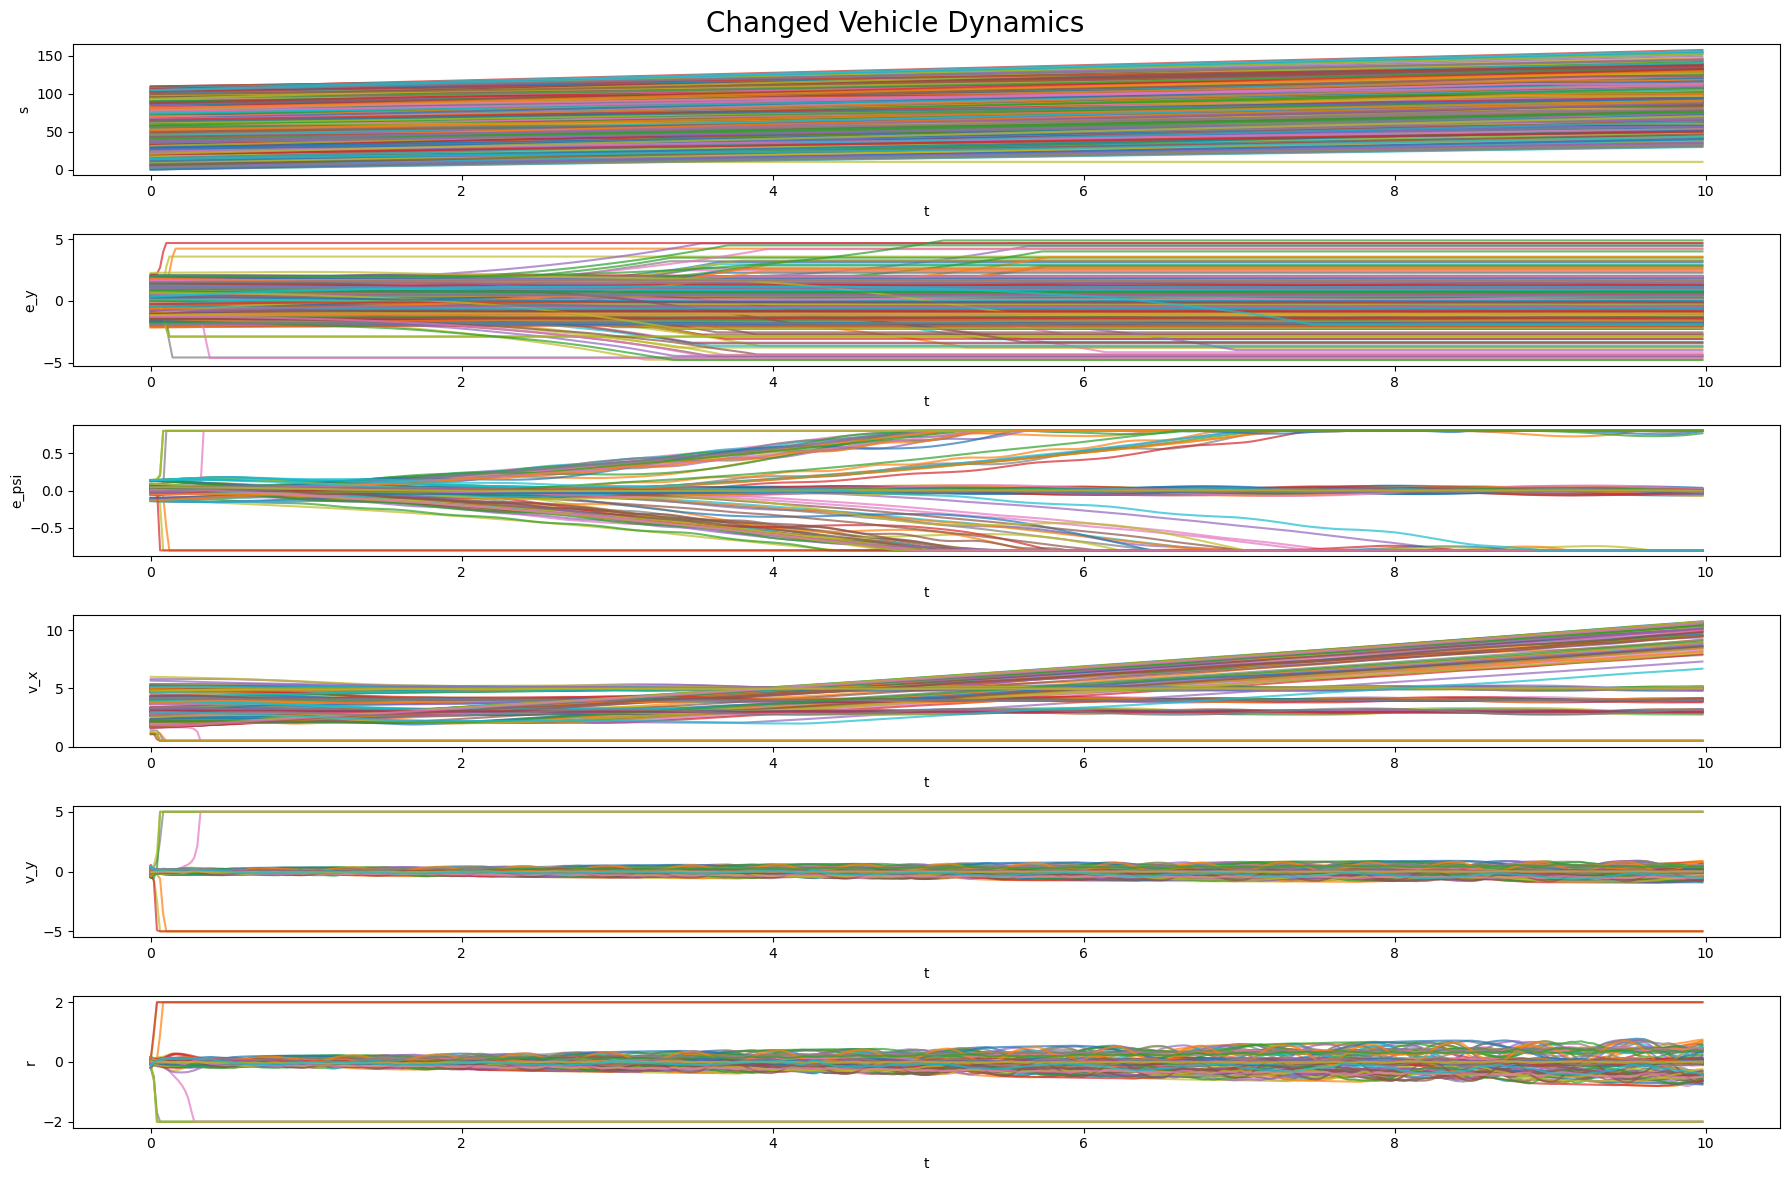

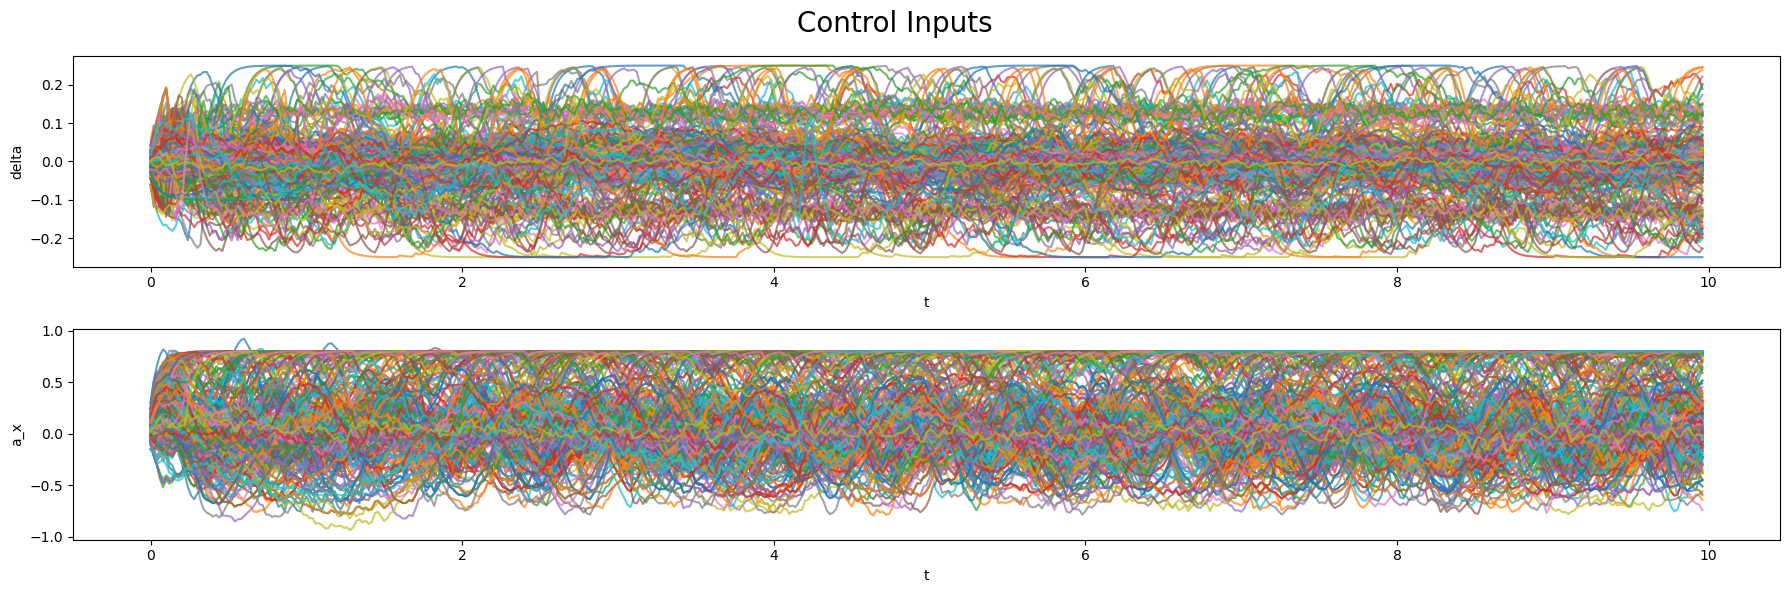

In [3]:

# =============================================================================
# 系统拟合
# =============================================================================
linear = True
set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])

# =============================================================================
# 数据生成 (针对 100m 双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

sys_pars_base["road_modes"] = ['dlc']
sys_pars_base["road_mode_probs"] = [1.0]

sys_pars_base["u_modes"] = ['feedback_dominant', 'sinusoidal', 'mixed']
sys_pars_base["u_mode_probs"] = [0.40, 0.30, 0.30]  # 稍微调整激励比例

sys_pars_base["alpha_u"] = 0.70
sys_pars_base["s_margin"] = 15.0
sys_pars_base["seed"] = RUN_CFG["seed"]

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

# sys_pars_new_base = dict(sys_pars_base)

sensor_noise = False
SNR_DB = 30
num_snaps = 500

configs = [
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.20, "ax_max": 1.0, "freq": 0.5},  # 低频大转角，逼近紧急 DLC
    {"vx_ref": 4.0, "delta_max": 0.15, "ax_max": 0.8, "freq": 0.2},  # 中高速覆盖，拉大 e_y 侧移
    {"vx_ref": 5.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 高速覆盖
    {"vx_ref": 2.0, "delta_max": 0.25, "ax_max": 0.8, "freq": 0.5},  # 低速极大转角
]

num_traj_per_batch = 80
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)

    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)

    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(RUN_CFG["seed"])
random.seed(RUN_CFG["seed"])
for i in range(num_traj):
    s_shift = np.random.uniform(0.0, 110.0)  # 覆盖 DLC 的 100m 长度
    ey_shift = np.random.uniform(-2.0, 2.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度

    X[i, :, 0] += s_shift
    X_changed[i, :, 0] += s_shift
    X[i, :, 1] += ey_shift
    X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim20_dt_0.02.pth
历史模型读取失败，跳过历史平滑: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL core.koopman_core_linear_GPU.KoopDNN_linear was not an allowed global by default. Please use `torch.serialization.add_safe_globals([core.koopman_core_linear_GPU.KoopDNN_linear])` or the `torch.serialization.safe_globals([core.koopman_core_linear_GPU.KoopDNN_linear])` contex

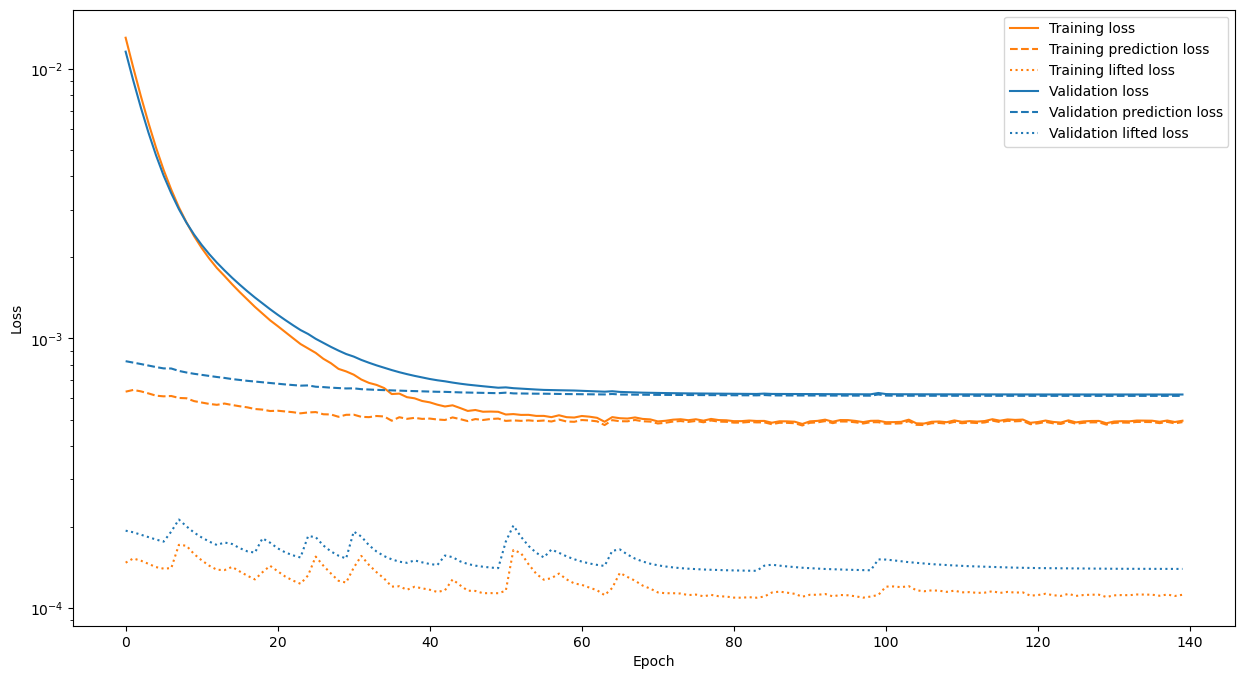

In [4]:
# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = KOOPMAN_CFG["encoder_hidden_width"]
net_params_lin["encoder_hidden_depth"] = KOOPMAN_CFG["encoder_hidden_depth"]
net_params_lin["encoder_output_dim"] = KOOPMAN_CFG["encoder_output_dim"]
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = KOOPMAN_CFG["lr"]
net_params_lin["epochs"] = KOOPMAN_CFG["epochs"]
net_params_lin["batch_size"] = KOOPMAN_CFG["batch_size"]

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.20
net_params_lin["lifted_loss_penalty"] = 0.05

net_params_lin["l2_reg"] = 1e-4
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt
net_params_lin["weight_decay"] = KOOPMAN_CFG["weight_decay"]

train = RUN_CFG["enable_koopman_training"]
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
torch.cuda.empty_cache()

prev_A = prev_B = None
if RUN_CFG["enable_koopman_linear_refit"] and os.path.exists(file_koop_linear):
    try:
        prev_model = torch.load(file_koop_linear, map_location=DEVICE)
        if not hasattr(prev_model, "A_lin") or not hasattr(prev_model, "B_lin"):
            prev_model.construct_koopman_model()
        prev_A = np.array(prev_model.A_lin, dtype=np.float32)
        prev_B = np.array(prev_model.B_lin, dtype=np.float32)
        print("检测到历史模型，将用于平滑本次线性矩阵。")
    except Exception as e:
        print("历史模型读取失败，跳过历史平滑:", e)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)

    # 强制对齐：x 和 u 的时间维以最小长度为准
    min_t_train = min(xs_train.shape[1], us_train.shape[1])
    xs_train = xs_train[:, :min_t_train, :]
    us_train = us_train[:, :min_t_train, :]

    min_t_val = min(xs_val.shape[1], us_val.shape[1])
    xs_val = xs_val[:, :min_t_val, :]
    us_val = us_val[:, :min_t_val, :]

    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )

    X_train, y_train = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_train, data_u=model_koop_dnn_lin.u_train
    )
    X_val, y_val = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_val, data_u=model_koop_dnn_lin.u_val, train_mode=False
    )

    from torch.utils.data import TensorDataset, DataLoader

    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float()
    X_val_t = torch.from_numpy(X_val).float()
    y_val_t = torch.from_numpy(y_val).float()

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(RUN_CFG["seed"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        persistent_workers=False,
        prefetch_factor=None,
        generator=loader_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model_koop_dnn_lin.train_loader = train_loader
    model_koop_dnn_lin.val_loader = val_loader

    model_koop_dnn_lin.model_pipeline(net_params_lin, print_epoch=True)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

# 始终构造一次线性 Koopman 矩阵（供 MPC 使用）
model_koop_dnn_lin.construct_koopman_model()

if RUN_CFG["enable_koopman_linear_refit"]:
    A_fit, B_fit, fit_info = fit_koopman_linear_matrices(
        model_koop_dnn_lin,
        xs_train,
        us_train,
        ridge_lambda=KOOPMAN_CFG["ridge_lambda"],
        batch_size=8192
    )

    A_refined = blend_matrix(model_koop_dnn_lin.A_lin.astype(np.float32), A_fit, KOOPMAN_CFG["linear_fit_blend"])
    B_refined = blend_matrix(model_koop_dnn_lin.B_lin.astype(np.float32), B_fit, KOOPMAN_CFG["linear_fit_blend"])

    if prev_A is not None and prev_B is not None:
        A_refined = blend_matrix(A_refined, prev_A, KOOPMAN_CFG["previous_model_blend"])
        B_refined = blend_matrix(B_refined, prev_B, KOOPMAN_CFG["previous_model_blend"])

    model_koop_dnn_lin.A_lin = A_refined
    model_koop_dnn_lin.B_lin = B_refined

    with torch.no_grad():
        model_koop_dnn_lin.net.A.weight.copy_(torch.from_numpy(A_refined).to(DEVICE))
        model_koop_dnn_lin.net.B.weight.copy_(torch.from_numpy(B_refined).to(DEVICE))

    print(f"线性重拟合完成: samples={fit_info['samples']}, lifted_rmse={fit_info['lifted_rmse']:.4e}")

if train:
    torch.save(model_koop_dnn_lin, file_koop_linear)

if len(model_koop_dnn_lin.train_loss_hist) > 0 and len(model_koop_dnn_lin.val_loss_hist) > 0:
    train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
    train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
    train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
    val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
    val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
    val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
    epochs = np.arange(0, len(train_loss))

    plt.figure(figsize=(15, 8))
    plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
    plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
    plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
    plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
    plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
    plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.show()
else:
    print("未执行本轮训练，跳过训练曲线绘制。")


A, B, C shapes: (27, 27) (27, 2) (6, 27)
stable spectral radius = 0.9990002
A, B, C shapes: (27, 27) (27, 2) (6, 27)
spectral radius = 1.0026661
eigvals = [0.8401652 +0.14437214j 0.8401652 -0.14437214j 1.0026661 +0.j
 1.0015767 +0.j         0.9996563 +0.00032682j 0.9996563 -0.00032682j
 0.9984175 +0.j         0.39533237+0.01308122j 0.39533237-0.01308122j
 0.39415804+0.01015002j 0.39415804-0.01015002j 0.39587572+0.00758387j
 0.39587572-0.00758387j 0.39606658+0.00547414j 0.39606658-0.00547414j
 0.3928809 +0.00472764j 0.3928809 -0.00472764j 0.394232  +0.00457023j
 0.394232  -0.00457023j 0.39591184+0.00338242j 0.39591184-0.00338242j
 0.39353988+0.00279234j 0.39353988-0.00279234j 0.39418772+0.00162898j
 0.39418772-0.00162898j 0.3941409 +0.j         0.39369303+0.j        ]


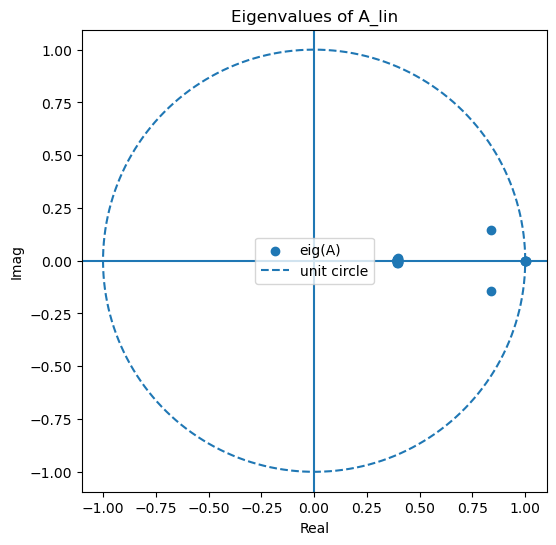

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)


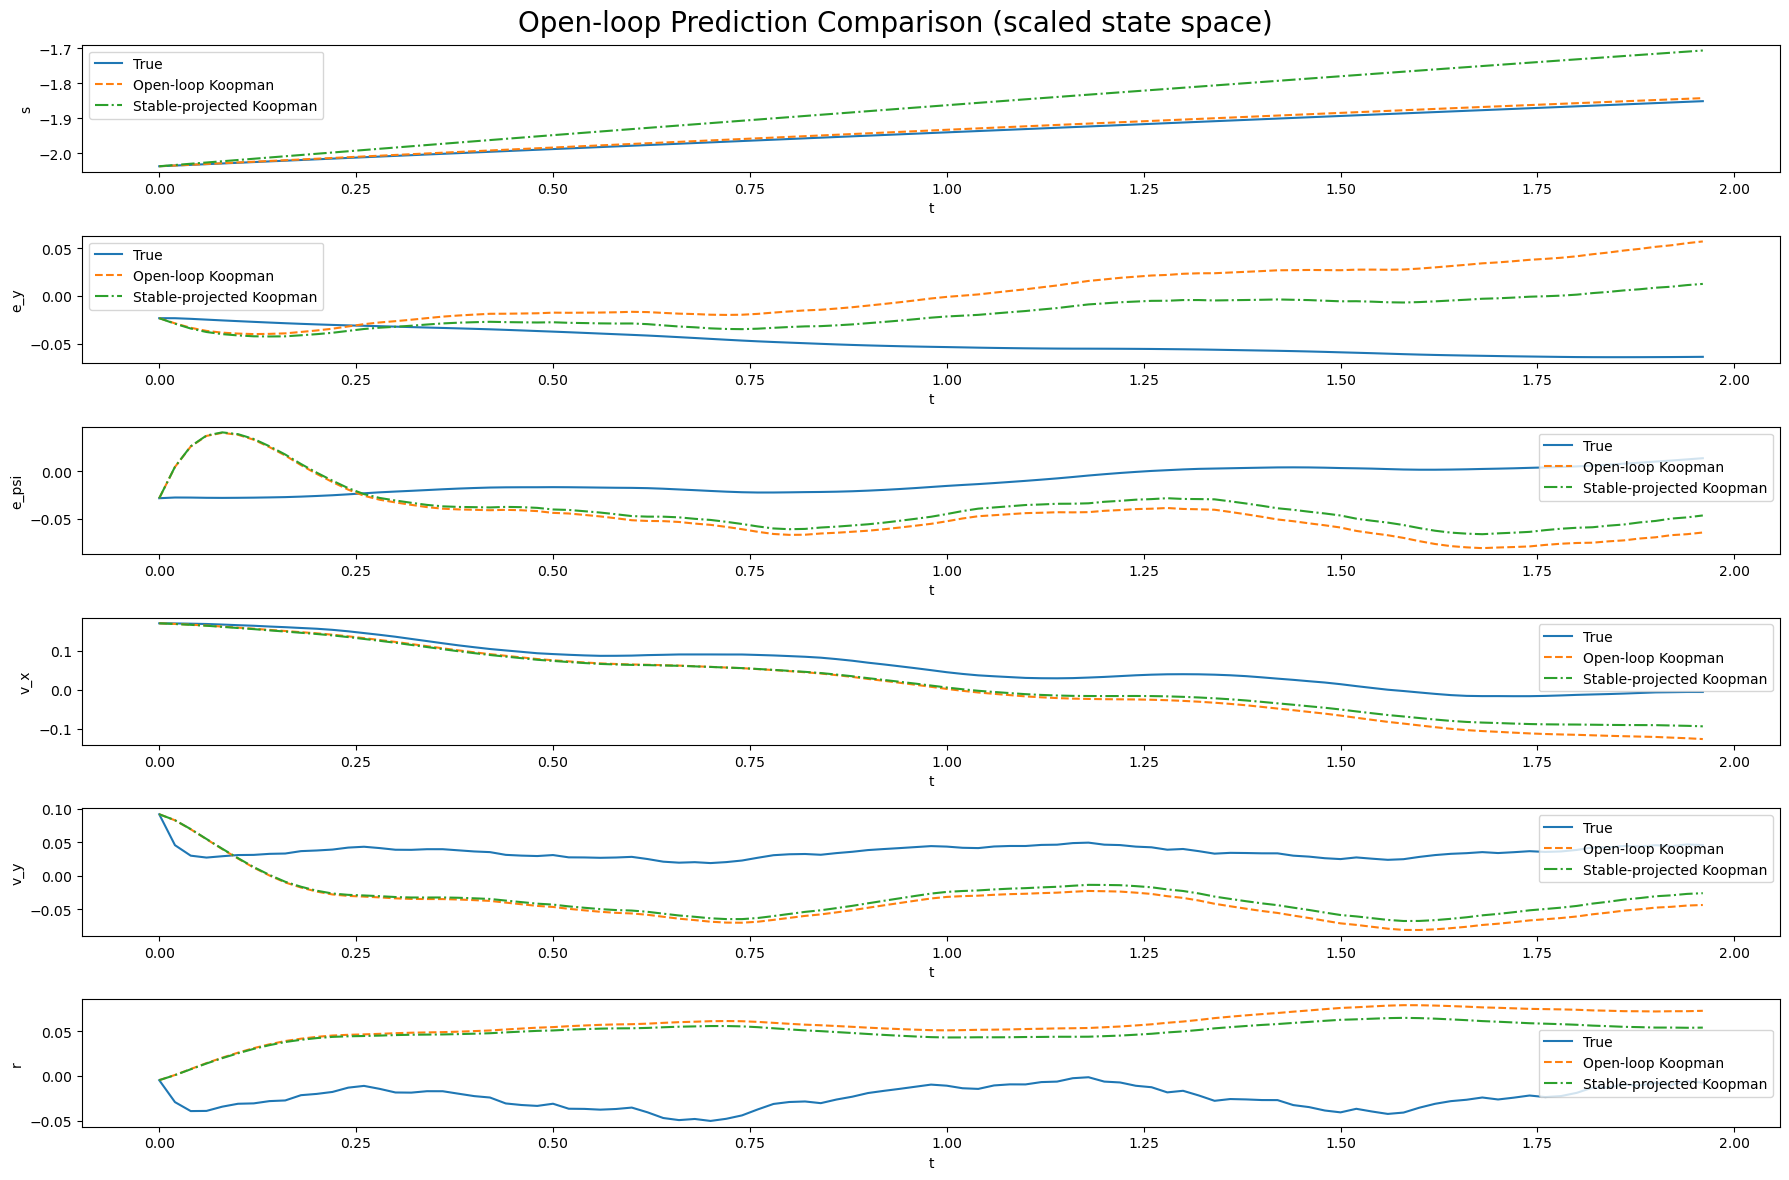

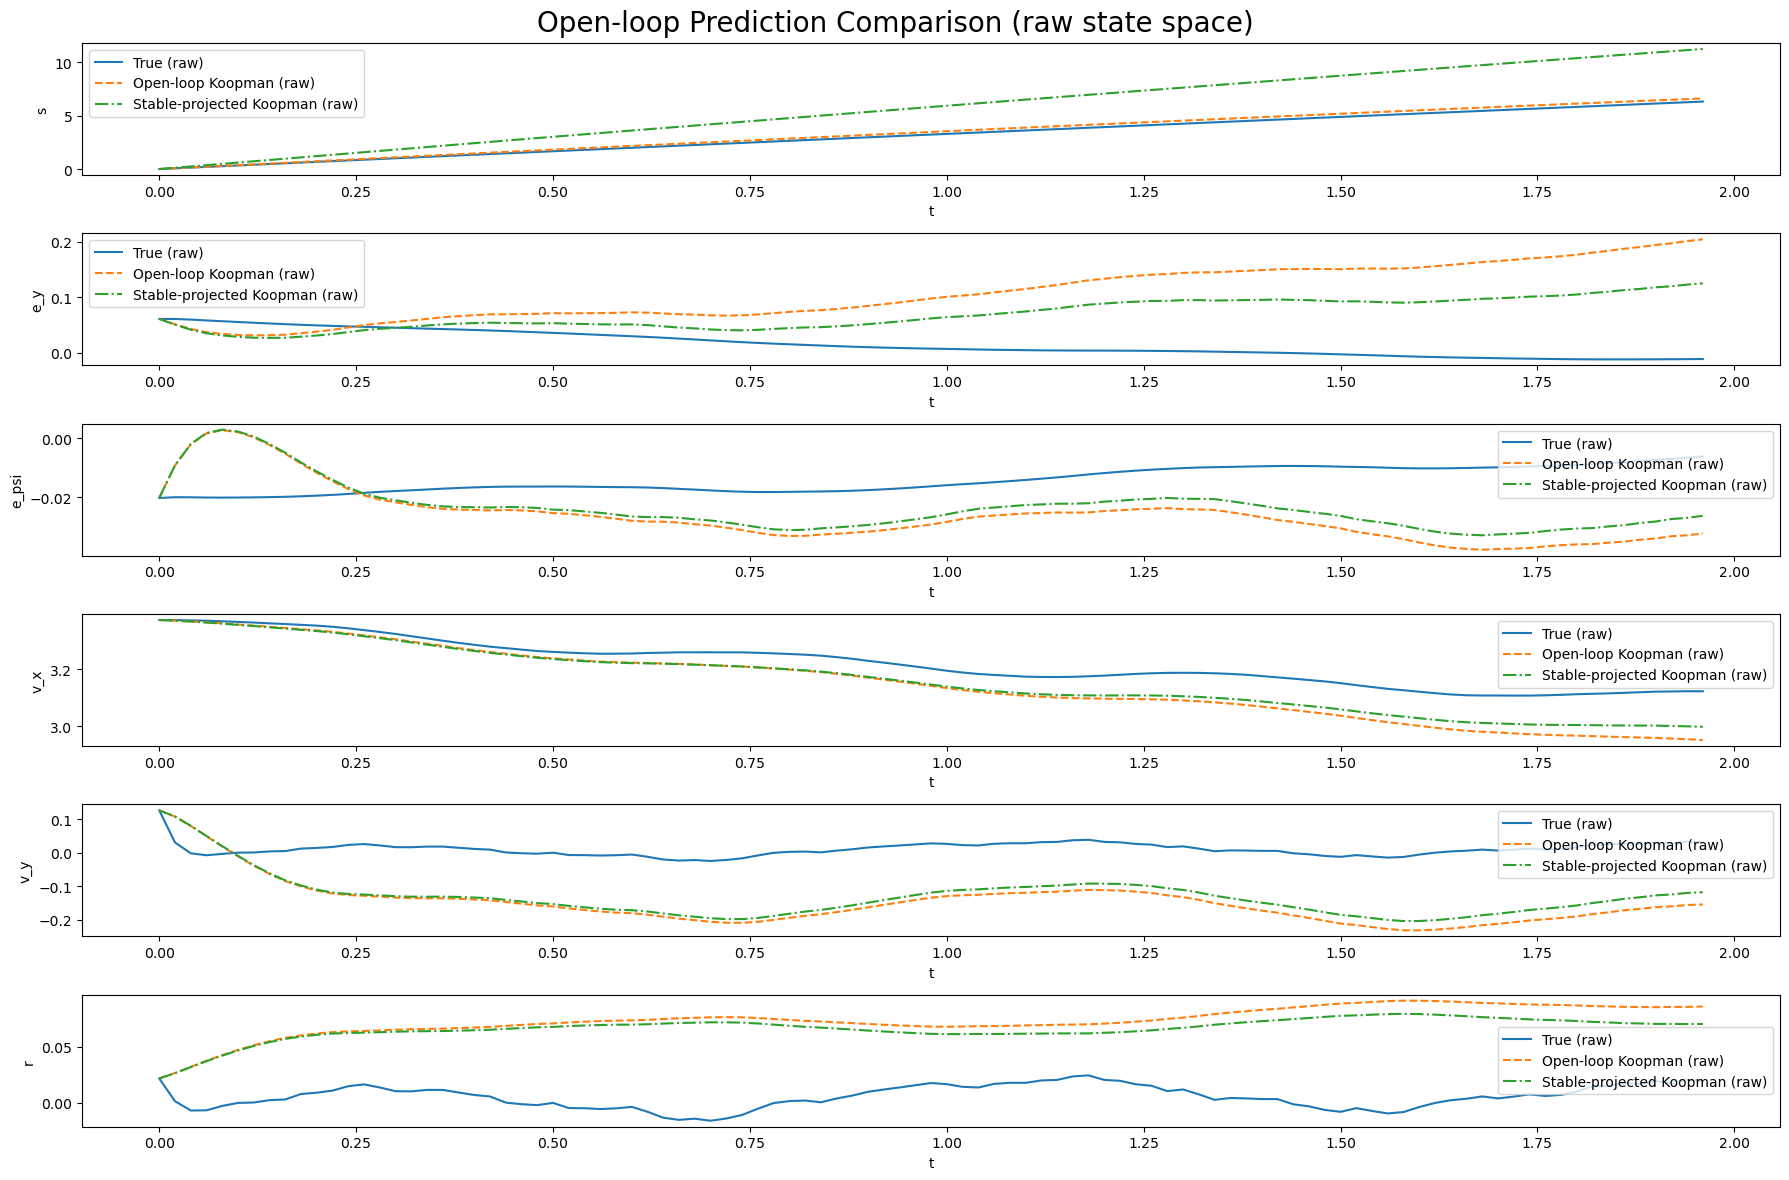

In [5]:

# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

# ====================== 正确提取 Koopman 矩阵 ======================
# ====================== 正确提取 Koopman 矩阵 ======================
if not hasattr(model_koop_dnn_lin, 'A_lin'):
    print("⚠️ 尚未调用 construct_koopman_model()，现在自动调用...")
    model_koop_dnn_lin.construct_koopman_model()

A_lin = model_koop_dnn_lin.A_lin
B_lin = model_koop_dnn_lin.B_lin
C_lin = model_koop_dnn_lin.C_np

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)

x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

进行 one-step 预测 | 样本数: 99 | 状态维: 6


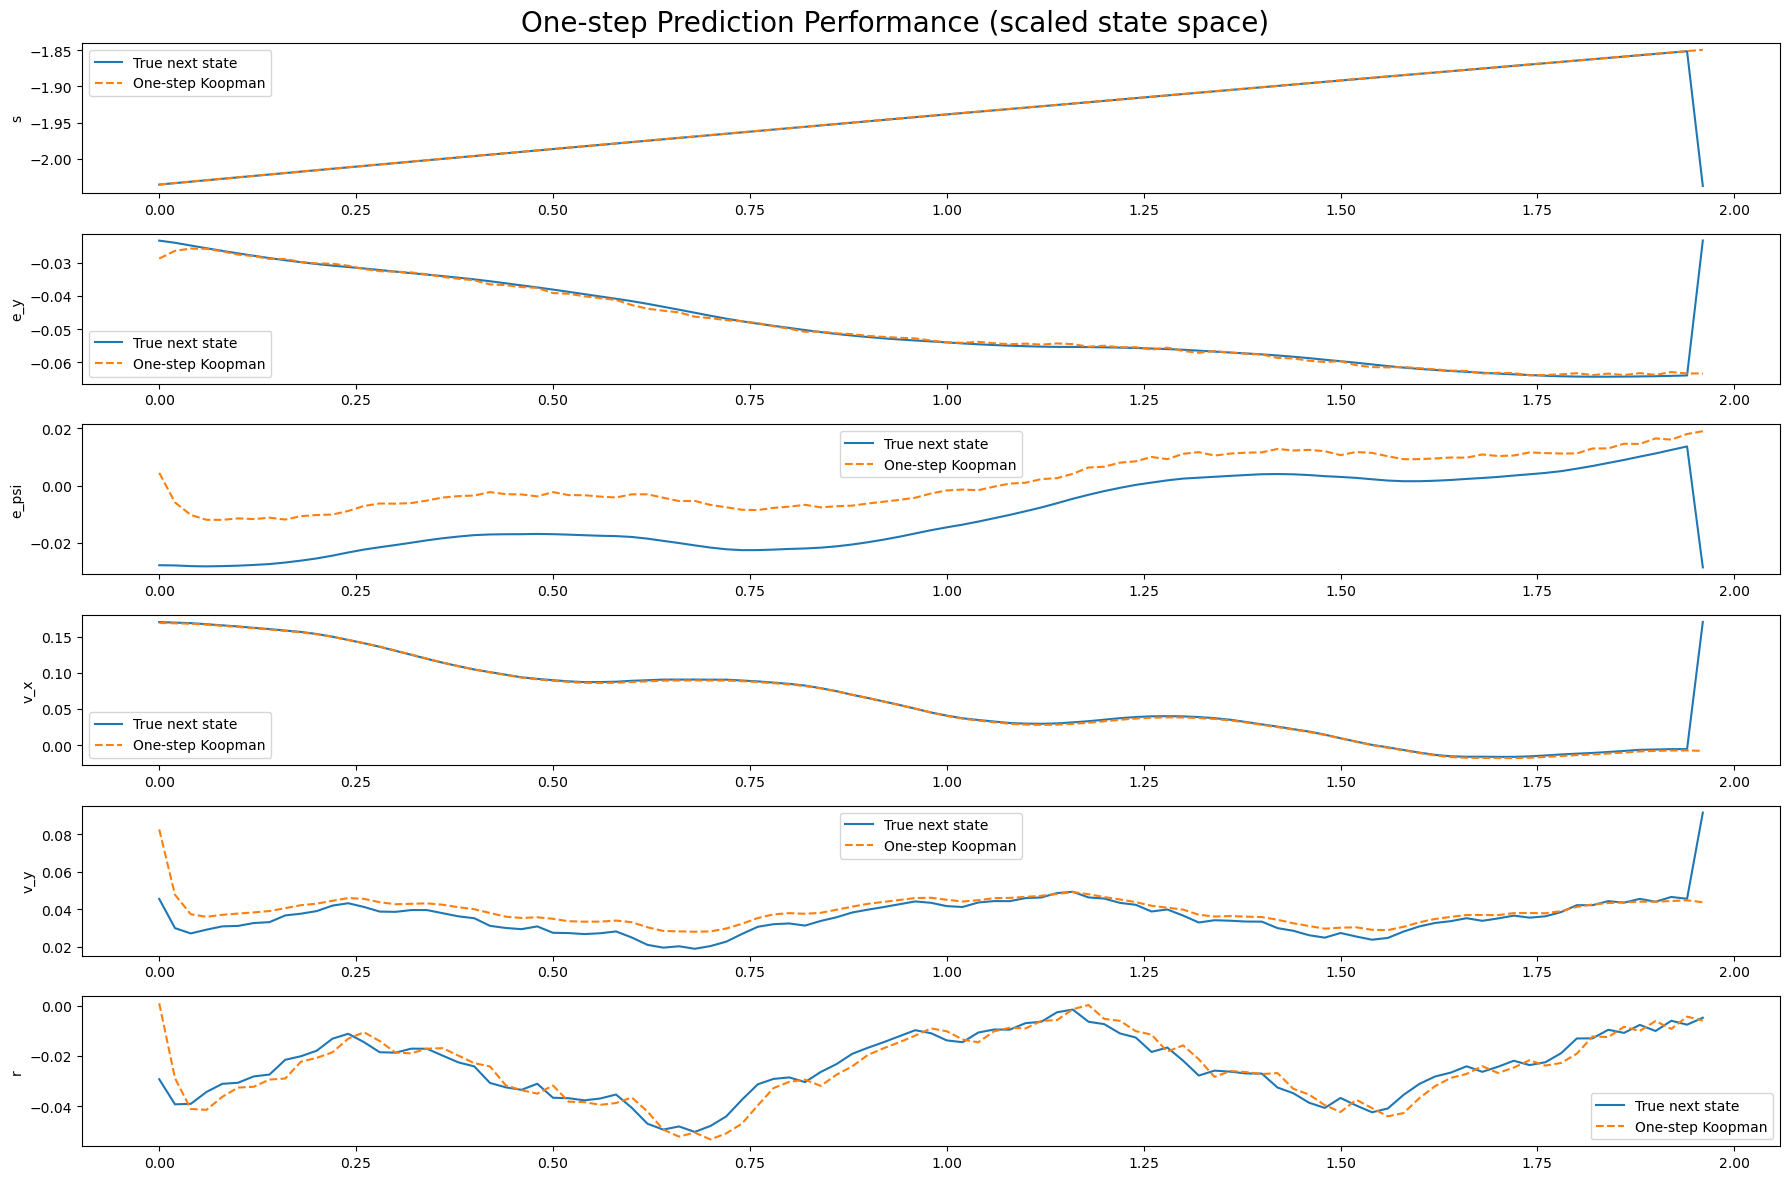

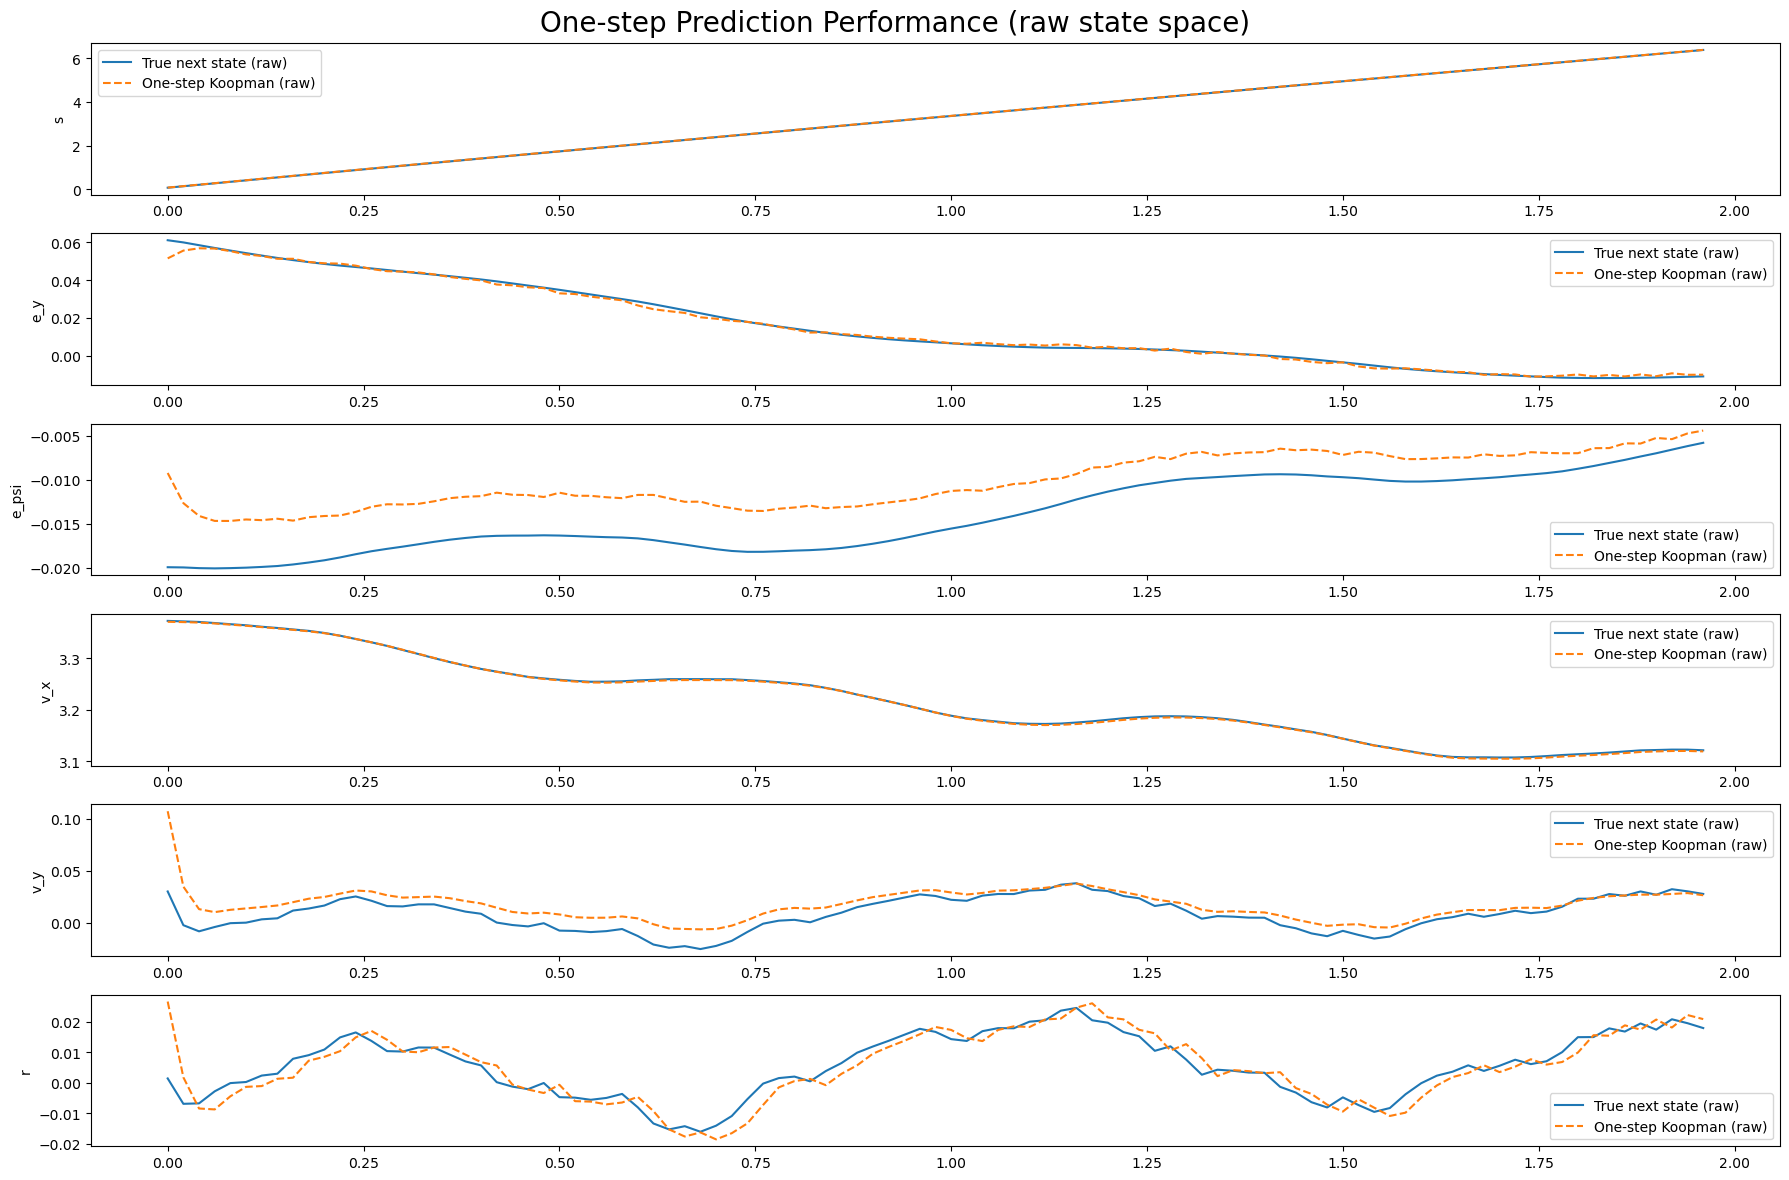

In [6]:

# ====================== One-step Prediction (修复空数组问题) ======================
# 正确计算有效样本数（process 已经切掉了最后一步）
num_pred = x_unchanged_scaled.shape[0]  # 应该等于 99

# 正确初始化（使用 num_pred 而不是像 x_unchanged_prime_scaled 这样可能为空的变量）
x_one_step_pred = np.zeros((num_pred, num_states))

print(f"进行 one-step 预测 | 样本数: {num_pred} | 状态维: {num_states}")

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(num_pred) * dt

# ====================== 绘图（scaled） ======================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)

    # 更符合逻辑的替代写法
    true_next = x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[1] > 0 else np.roll(
        x_unchanged_scaled[:, i], -1)
    plt.plot(T_plot_1, true_next, label="True next state")

    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== 绘图（raw） ======================
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)

# True next state（注意对齐）
x_true_next_raw = x_unchanged_test[0, 1:1 + num_pred, :]

T_plot_raw = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

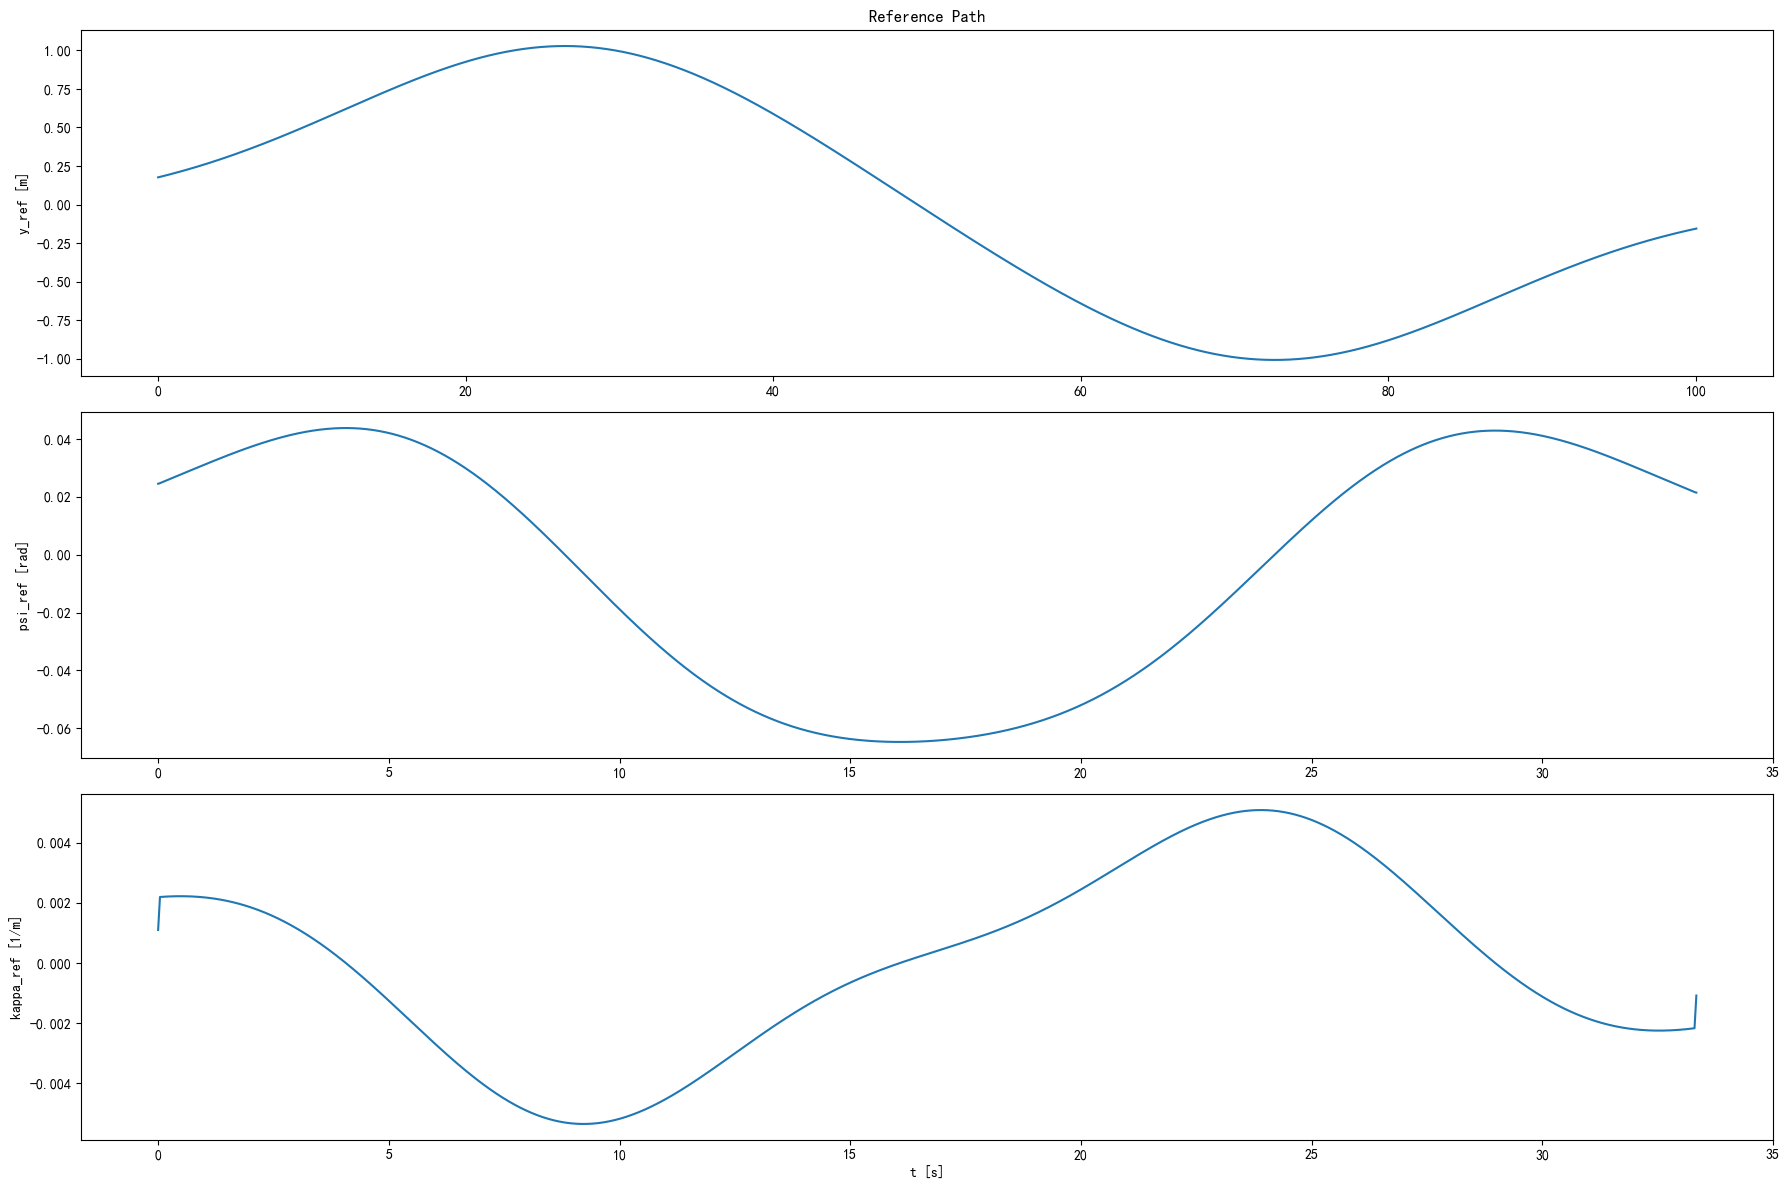

In [28]:
#
#=============================================================================
# Testing - 100m Double Lane Change Baseline
# =============================================================================

# =========================
# 四车参数统一定义（可开关）
# =========================
d_spacing = 5.0
num_vehicles = 4 if RUN_CFG["enable_four_vehicle"] else 1
vx_nom = 3.0

formation_offsets = [
    (0.0, 0.20),
    (0.0, -0.20),
    (-d_spacing, 0.20),
    (-d_spacing, -0.20),
]

x0_vehicles = []
for idx in range(num_vehicles):
    ds, dey = formation_offsets[idx]
    x0_vehicles.append(np.array([ds, dey, 0.0, vx_nom, 0.0, 0.0]))

# =========================
# Reference path generation
# =========================
path_length = MPC_CFG["path_length"]
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

if RUN_CFG["enable_curved_tracking"]:
    # 更大曲率双移线：增大横向幅值 + 缩小过渡宽度
    A1 = 1
    A2 = -1
    x1 = 27.0
    x2 = 73.0
    sigma1 = 14.5
    sigma2 = 14.5

    y_ref_dlc = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
    )

    # 叠加轻微波动，让弯道段曲率变化更明显
    y_ref_wave = 0.05 * np.sin(2.0 * np.pi * 1.3 * x_path / path_length) * np.exp(
        -((x_path - 0.5 * path_length) / (0.55 * path_length)) ** 2
    )

    y_ref_path = y_ref_dlc + y_ref_wave
else:
    y_ref_path = np.zeros_like(x_path)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()


In [29]:
# =========================
# Solver settings（防卡死调优 + 可开关）
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 3
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 10
solver_settings["max_iter"] = 6000
solver_settings["eps_abs"] = 8e-4
solver_settings["eps_rel"] = 8e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3
solver_settings["sqp_step_size"] = 0.85
solver_settings["du_clip"] = 0.45
solver_settings["retry_on_fail"] = 1
solver_settings["retry_relax_factor"] = 1.8
solver_settings["accept_solved_inaccurate"] = True
solver_settings["accept_partial_solution"] = True
solver_settings["accept_partial_prim_res"] = 4e-3
solver_settings["accept_partial_dual_res"] = 4e-3
solver_settings["verbose"] = False

if RUN_CFG["enable_solver_guard"]:
    solver_settings["time_limit"] = MPC_CFG["osqp_time_limit"]

# 初始化参考轨迹列表
x_ref_mpc_vehicles = []


In [30]:
# =========================
# MPC horizon / ref preview
# =========================
N_lin_noadapt = MPC_CFG["horizon"]
max_iter_lin = MPC_CFG["max_sqp_iters"]

for v in range(num_vehicles):
    x_ref_raw_v = x_ref_raw.copy()
    x_ref_raw_v[0, :] += x0_vehicles[v][0]
    x_ref_raw_v[1, :] = x0_vehicles[v][1]
    x_ref_raw_v[2, :] = 0.0
    x_ref_raw_v[3, :] = vx_nom
    x_ref_raw_v[4:, :] = 0.0

    x_ref_scaled_v = standardizer_x_kdnn.transform(x_ref_raw_v.T).T

    x_ref_mpc_v = np.hstack((
        x_ref_scaled_v,
        np.tile(x_ref_scaled_v[:, -1].reshape(-1, 1), N_lin_noadapt + 2)
    ))
    x_ref_mpc_vehicles.append(x_ref_mpc_v)

# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0])
xmax_raw = np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([0.08, 1.0])
umin_lin_noadapt = -umax_lin_noadapt

# =========================
# Closed-loop arrays in raw space
# =========================
xt_actual_vehicles = [np.zeros((traj_length, num_states)) for _ in range(num_vehicles)]
for v in range(num_vehicles):
    xt_actual_vehicles[v][0, :] = x0_vehicles[v]

u_vehicles = [np.zeros((traj_length - 1, num_inputs)) for _ in range(num_vehicles)]
z_vehicles = [np.zeros((traj_length, n_obs_lin)) for _ in range(num_vehicles)]

n_lift = A_lin.shape[0]

# ====================== 基础权重 ======================
Q_base_lin = scipy.sparse.diags([
    0.0,
    3500.0,
    1200.0,
    8.0,
    1.0,
    1.0
])

QN_base_lin = scipy.sparse.diags([
    0.0,
    5000.0,
    2000.0,
    12.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([120.0, 12.0])


In [31]:
# =========================
# Controller
# =========================
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

controllers = []
z_inits = []

for v in range(num_vehicles):
    x_init_raw_v = np.tile(x0_vehicles[v], (N_lin_noadapt + 1, 1))
    u_init_v = np.zeros((N_lin_noadapt, num_inputs))
    z_init_v = np.zeros((N_lin_noadapt + 1, n_lift))

    for ii in range(N_lin_noadapt + 1):
        xii_scaled = scale_state(x_init_raw_v[ii, :], standardizer_x_kdnn)
        z_init_v[ii, :] = lift_scaled(xii_scaled, model_koop_dnn_lin, net_params_lin)

    z_inits.append(z_init_v)

    ppc_params = {
        "rho_ey_0": PPC_CFG["rho_ey_0"],
        "rho_ey_inf": PPC_CFG["rho_ey_inf"],
        "lambda_ey": PPC_CFG["lambda_ey"],
        "rho_epsi_0": PPC_CFG["rho_epsi_0"],
        "rho_epsi_inf": PPC_CFG["rho_epsi_inf"],
        "lambda_epsi": PPC_CFG["lambda_epsi"],
    }

    ctrl_v = NonlinearMPCController(
        linear_model_no_adapt,
        N_lin_noadapt, dt, umin_lin_noadapt, umax_lin_noadapt,
        xmin_lin_noadapt, xmax_lin_noadapt,
        Q_base_lin, R_mpc_lin_noadapt, QN_base_lin,
        solver_settings,
        add_ppc_soft=RUN_CFG["enable_ppc_soft_constraints"],
        q_slack_ey=4e4,
        q_slack_epsi=3e4,
        p_slack_ey=4e3,
        p_slack_epsi=3e3,
        ppc_params=ppc_params
    )

    ctrl_v.construct_controller(
        z_init_v,
        u_init_v,
        x_ref_mpc_vehicles[v][:, :N_lin_noadapt + 1]
    )

    controllers.append(ctrl_v)


# =========================
# 自适应权重（可开关 + 平滑 + 限幅）
# =========================
weight_memory = [{"ey": 1.0, "epsi": 1.0, "r": 1.0} for _ in range(num_vehicles)]


def adaptive_mpc_weights(error_ey, error_epsi, base_Q, base_QN, base_R, prev_mem=None):
    ey_norm = min(abs(error_ey) / 1.8, 1.0)
    epsi_norm = min(abs(error_epsi) / 0.7, 1.0)

    mult_ey = 1.0 + 1.8 * (ey_norm ** 1.1)
    mult_epsi = 1.0 + 1.8 * (epsi_norm ** 1.1)

    mult_ey = np.clip(mult_ey, 0.85, 2.8)
    mult_epsi = np.clip(mult_epsi, 0.85, 2.8)

    if prev_mem is not None:
        rate = MPC_CFG["weight_rate_limit"]
        smooth = MPC_CFG["weight_smoothing"]

        mult_ey = np.clip(mult_ey, prev_mem["ey"] - rate, prev_mem["ey"] + rate)
        mult_epsi = np.clip(mult_epsi, prev_mem["epsi"] - rate, prev_mem["epsi"] + rate)

        mult_ey = smooth * prev_mem["ey"] + (1.0 - smooth) * mult_ey
        mult_epsi = smooth * prev_mem["epsi"] + (1.0 - smooth) * mult_epsi

    Q_diag = base_Q.diagonal().copy()
    QN_diag = base_QN.diagonal().copy()

    Q_diag[1] *= mult_ey
    Q_diag[2] *= mult_epsi
    QN_diag[1] *= mult_ey * 1.25
    QN_diag[2] *= mult_epsi * 1.25

    Q_adapt = scipy.sparse.diags(Q_diag, offsets=0, format='dia')
    QN_adapt = scipy.sparse.diags(QN_diag, offsets=0, format='dia')

    R_diag = base_R.diagonal().copy()
    mult_r = np.clip(1.0 - 0.22 * (max(mult_ey, mult_epsi) - 1.0), 0.76, 1.0)
    R_adapt = scipy.sparse.diags(R_diag * mult_r, offsets=0, format='dia')

    return Q_adapt, QN_adapt, R_adapt, {"ey": float(mult_ey), "epsi": float(mult_epsi), "r": float(mult_r)}


def maybe_update_ppc(controller, curvature_now):
    if not (RUN_CFG["enable_ppc_soft_constraints"] and RUN_CFG["enable_dynamic_ppc"]):
        return

    curv_norm = min(abs(curvature_now) / max(PPC_CFG["curvature_norm"], 1e-6), 1.0)
    scale = 1.0 + PPC_CFG["curvature_gain"] * curv_norm

    p = dict(controller.ppc_params)
    p["rho_ey_0"] = PPC_CFG["rho_ey_0"] / scale
    p["rho_epsi_0"] = PPC_CFG["rho_epsi_0"] / scale
    p["rho_ey_inf"] = max(0.012, PPC_CFG["rho_ey_inf"] / scale)
    p["rho_epsi_inf"] = max(0.010, PPC_CFG["rho_epsi_inf"] / scale)
    p["lambda_ey"] = PPC_CFG["lambda_ey"] * (1.0 + 0.2 * curv_norm)
    p["lambda_epsi"] = PPC_CFG["lambda_epsi"] * (1.0 + 0.2 * curv_norm)

    controller.ppc_params = p


formation_targets = []
leader_idx = FORMATION_CFG["leader_index"]
for v in range(num_vehicles):
    formation_targets.append({
        "ds": float(x0_vehicles[v][0] - x0_vehicles[leader_idx][0]),
        "dey": float(x0_vehicles[v][1] - x0_vehicles[leader_idx][1])
    })


In [32]:
# =========================
# Closed-loop simulation
# =========================
delta_alpha = MPC_CFG["delta_alpha"]
ax_alpha = MPC_CFG["ax_alpha"]

sys_pars_ctrl = dict(sys_pars_new)
sys_pars_ctrl["vx_ref"] = vx_nom
sys_pars_ctrl["uncertainty"] = "NA"
sys_pars_ctrl["amp"] = 0.0
sys_pars_ctrl["freq"] = 1.0
sys_pars_ctrl["s_ref"] = s_ref_path
sys_pars_ctrl["curvature_ref"] = curvature_ref_path

begin_linear_noadapt = time.time()
begin_time = time.time()
fail_counts = [0] * num_vehicles
terminated_early = False
solver_status_hist = [[] for _ in range(num_vehicles)]

for k in range(traj_length - 1):
    leader_state_k = xt_actual_vehicles[leader_idx][k, :].copy()

    for v in range(num_vehicles):
        xk_raw = xt_actual_vehicles[v][k, :].copy()

        if not is_finite_vector(xk_raw):
            print(f"[STOP] 车{v + 1} 非有限状态 at step {k}")
            terminated_early = True
            break

        xk_raw = clip_closed_loop_state(xk_raw, s_upper=500.0)
        xt_actual_vehicles[v][k, :] = xk_raw

        # 可变权重矩阵（可开关）
        if RUN_CFG["enable_adaptive_weight_matrix"]:
            Q_adapt, QN_adapt, R_adapt, mem_new = adaptive_mpc_weights(
                xk_raw[1], xk_raw[2],
                Q_base_lin, QN_base_lin, R_mpc_lin_noadapt,
                prev_mem=weight_memory[v]
            )
            weight_memory[v] = mem_new
        else:
            Q_adapt, QN_adapt, R_adapt = Q_base_lin, QN_base_lin, R_mpc_lin_noadapt

        controllers[v].Q = Q_adapt
        controllers[v].QN = QN_adapt
        controllers[v].R = R_adapt

        maybe_update_ppc(controllers[v], curvature_ref_path[k])

        # scale & lift
        xk_scaled = scale_state(xk_raw, standardizer_x_kdnn)
        z_vehicles[v][k, :] = lift_scaled(xk_scaled, model_koop_dnn_lin, net_params_lin)

        # 参考窗口
        xref_win = x_ref_mpc_vehicles[v][:, k + 1:k + N_lin_noadapt + 2]

        # MPC 求解
        try:
            controllers[v].solve_to_convergence(
                xref_win, z_vehicles[v][k, :],
                controllers[v].z_init, controllers[v].u_init,
                max_iter=max_iter_lin, eps=1e-3
            )
            controllers[v].update_initial_guess_()
            delta_fb_mpc = float(controllers[v].cur_u[0, 0])
            ax_cmd = float(controllers[v].cur_u[0, 1])
            solver_status_hist[v].append(controllers[v].last_solve_info.get("status", "solved"))
        except Exception as e:
            fail_counts[v] += 1
            solver_status_hist[v].append("fallback")
            print(f"[WARN] 车{v + 1} MPC fallback at step {k}: {e}")
            if k > 0:
                delta_fb_mpc = float(u_vehicles[v][k - 1, 0])
                ax_cmd = float(u_vehicles[v][k - 1, 1])
            else:
                delta_fb_mpc, ax_cmd = 0.0, 0.0

        # 编队协同修正（可开关）
        if RUN_CFG["enable_cooperative_transport"] and num_vehicles > 1 and v != leader_idx:
            ds_err = (xk_raw[0] - leader_state_k[0]) - formation_targets[v]["ds"]
            dey_err = (xk_raw[1] - leader_state_k[1]) - formation_targets[v]["dey"]
            dpsi_err = xk_raw[2] - leader_state_k[2]
            dvx_err = xk_raw[3] - leader_state_k[3]

            delta_fb_mpc += -FORMATION_CFG["k_ey"] * dey_err - FORMATION_CFG["k_epsi"] * dpsi_err
            ax_cmd += -FORMATION_CFG["k_s"] * ds_err - FORMATION_CFG["k_vx"] * dvx_err

        # 前馈 + 裁剪
        ff_gain = MPC_CFG["ff_gain"] if RUN_CFG["enable_curved_tracking"] else 0.0
        delta_ff = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[k]
        delta_cmd = np.clip(delta_fb_mpc + delta_ff, umin_lin_noadapt[0], umax_lin_noadapt[0])
        ax_cmd = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

        # 输入平滑
        if k == 0:
            delta_applied = delta_cmd
            ax_applied = ax_cmd
        else:
            delta_applied = delta_alpha * u_vehicles[v][k - 1, 0] + (1.0 - delta_alpha) * delta_cmd
            ax_applied = ax_alpha * u_vehicles[v][k - 1, 1] + (1.0 - ax_alpha) * ax_cmd

        delta_applied = np.clip(delta_applied, umin_lin_noadapt[0], umax_lin_noadapt[0])
        ax_applied = np.clip(ax_applied, umin_lin_noadapt[1], umax_lin_noadapt[1])

        if k >= traj_length - 5 and k > 0:
            u_vehicles[v][k, :] = u_vehicles[v][k - 1, :]
        else:
            u_vehicles[v][k, 0] = delta_applied
            u_vehicles[v][k, 1] = ax_applied

        x_next = safe_FK_step(
            xt_actual_vehicles[v][k, :], u_vehicles[v][k, :],
            sys_pars_ctrl, SNR_DB=SNR_DB, i=k,
            fallback_state=xt_actual_vehicles[v][k, :].copy(), verbose=False
        )
        xt_actual_vehicles[v][k + 1, :] = x_next

    if terminated_early:
        break

    if (k + 1) % 120 == 0:
        print(f"step {k + 1}/{traj_length - 1} | fail_counts={fail_counts}")


[WARN] OSQP reached iteration/time limit with small residuals, accepting solution.
step 120/1667 | fail_counts=[0, 0, 0, 0]
step 240/1667 | fail_counts=[0, 0, 0, 0]
step 360/1667 | fail_counts=[0, 0, 0, 0]
step 480/1667 | fail_counts=[0, 0, 0, 0]
step 600/1667 | fail_counts=[0, 0, 0, 0]
step 720/1667 | fail_counts=[0, 0, 0, 0]
[WARN] OSQP solved inaccurate, accepting solution.
step 840/1667 | fail_counts=[0, 0, 0, 0]
step 960/1667 | fail_counts=[0, 0, 0, 0]
step 1080/1667 | fail_counts=[0, 0, 0, 0]
step 1200/1667 | fail_counts=[0, 0, 0, 0]
step 1320/1667 | fail_counts=[0, 0, 0, 0]
step 1440/1667 | fail_counts=[0, 0, 0, 0]
step 1560/1667 | fail_counts=[0, 0, 0, 0]


In [33]:

# =========================
# 仿真结束后的统计与打印
# =========================
end_linear_noadapt = time.time()

# 计算每辆车的有效控制步数（避免除零）
effective_steps_per_vehicle = []
for v in range(num_vehicles):
    u_v = u_vehicles[v]
    effective = max(1, np.sum(np.any(np.abs(u_v) > 0, axis=1)))
    effective_steps_per_vehicle.append(effective)
    print(f"车 {v + 1} 有效控制步数: {effective}")

# 整体平均 MPC 求解时间
total_time = end_linear_noadapt - begin_time
avg_time_per_step = total_time / max(1, traj_length - 1)

print("\n=== 四车协同仿真完成 ===")
print(f"总仿真时间: {total_time:.2f} 秒")
print(f"平均每步时间: {avg_time_per_step:.4f} 秒")
print(f"各车 MPC 失败次数: {fail_counts}")
print(f"提前终止: {terminated_early}")

# =========================
# 仿真结束统计
# =========================
end_time = time.time()
print(f"\n四车协同仿真完成，总耗时: {(end_time - begin_time):.2f} 秒")

for v in range(num_vehicles):
    effective = max(1, np.sum(np.any(np.abs(u_vehicles[v]) > 0, axis=1)))
    print(f"车 {v + 1} 有效控制步数: {effective} | MPC失败次数: {fail_counts[v]}")

print(f"提前终止: {terminated_early}")

车 1 有效控制步数: 1667
车 2 有效控制步数: 1667
车 3 有效控制步数: 1667
车 4 有效控制步数: 1667

=== 四车协同仿真完成 ===
总仿真时间: 544.45 秒
平均每步时间: 0.3266 秒
各车 MPC 失败次数: [0, 0, 0, 0]
提前终止: False

四车协同仿真完成，总耗时: 544.46 秒
车 1 有效控制步数: 1667 | MPC失败次数: 0
车 2 有效控制步数: 1667 | MPC失败次数: 0
车 3 有效控制步数: 1667 | MPC失败次数: 0
车 4 有效控制步数: 1667 | MPC失败次数: 0
提前终止: False


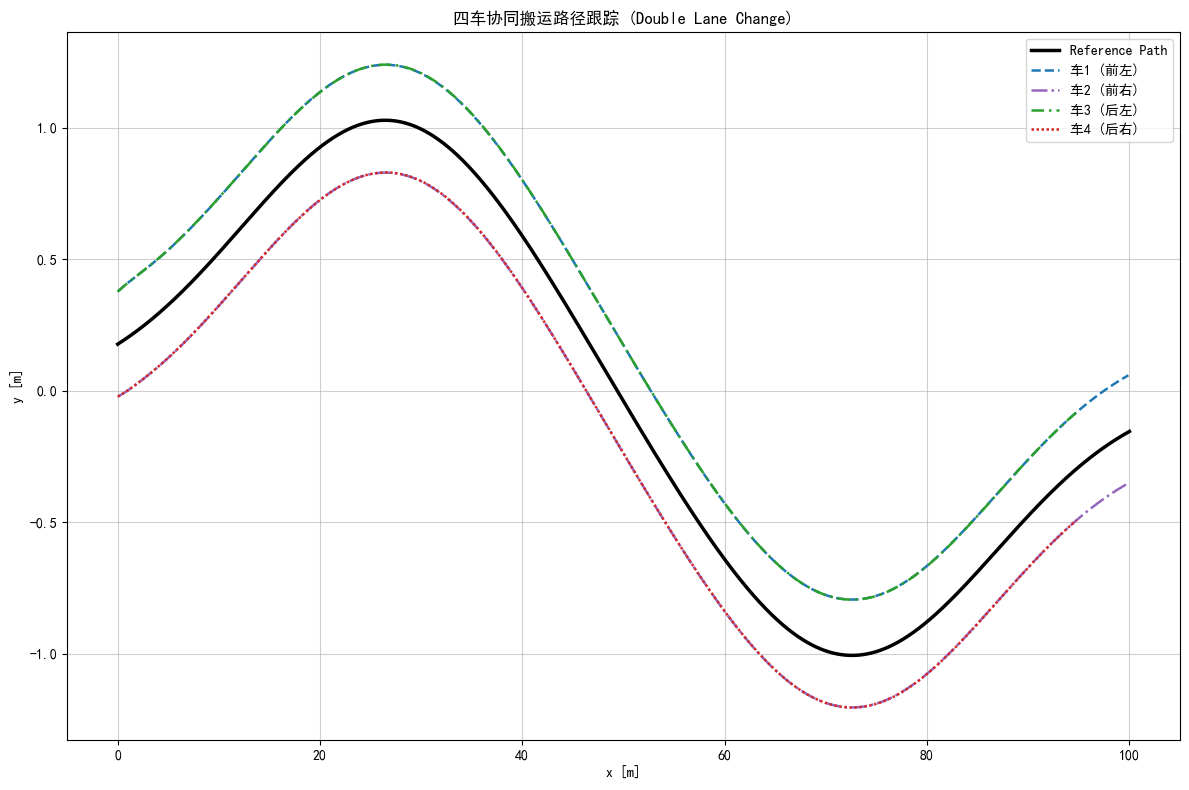


=== 各车轨迹诊断 ===
车1 → 有效步数: 1668/1668 | 最终s位置: 100.01 m
车2 → 有效步数: 1668/1668 | 最终s位置: 100.05 m
车3 → 有效步数: 1668/1668 | 最终s位置: 94.81 m
车4 → 有效步数: 1668/1668 | 最终s位置: 94.84 m


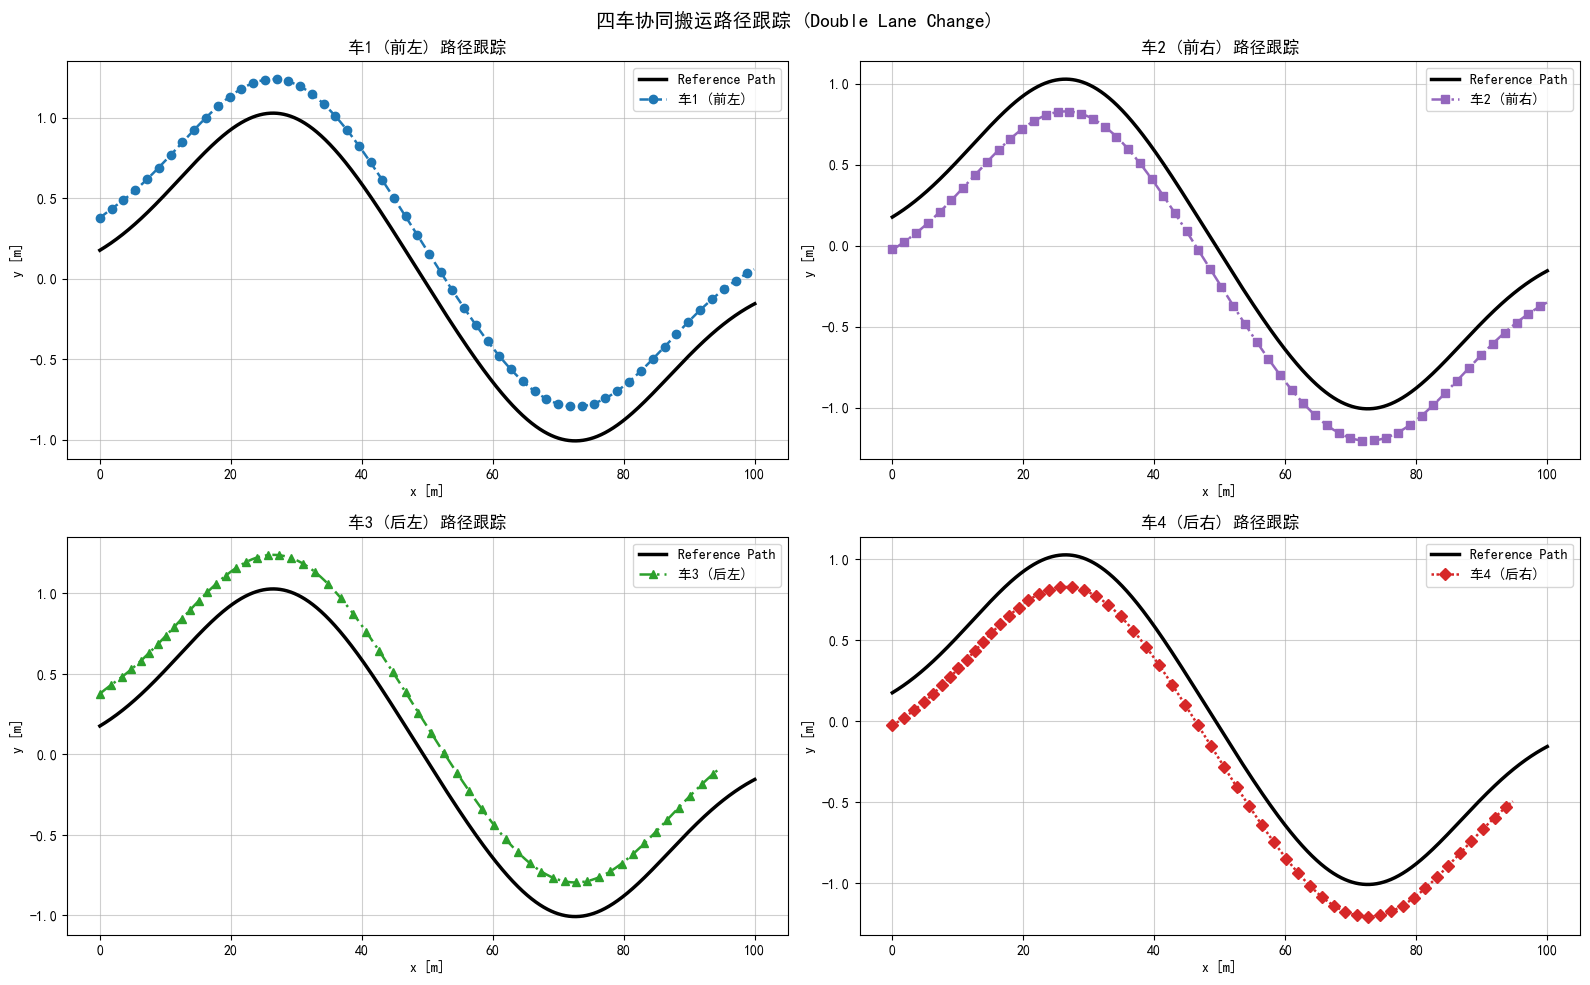


=== 各车轨迹诊断 ===
车1 → 有效步数: 1668/1668 | 最终s位置: 100.01 m
车2 → 有效步数: 1668/1668 | 最终s位置: 100.05 m
车3 → 有效步数: 1668/1668 | 最终s位置: 94.81 m
车4 → 有效步数: 1668/1668 | 最终s位置: 94.84 m


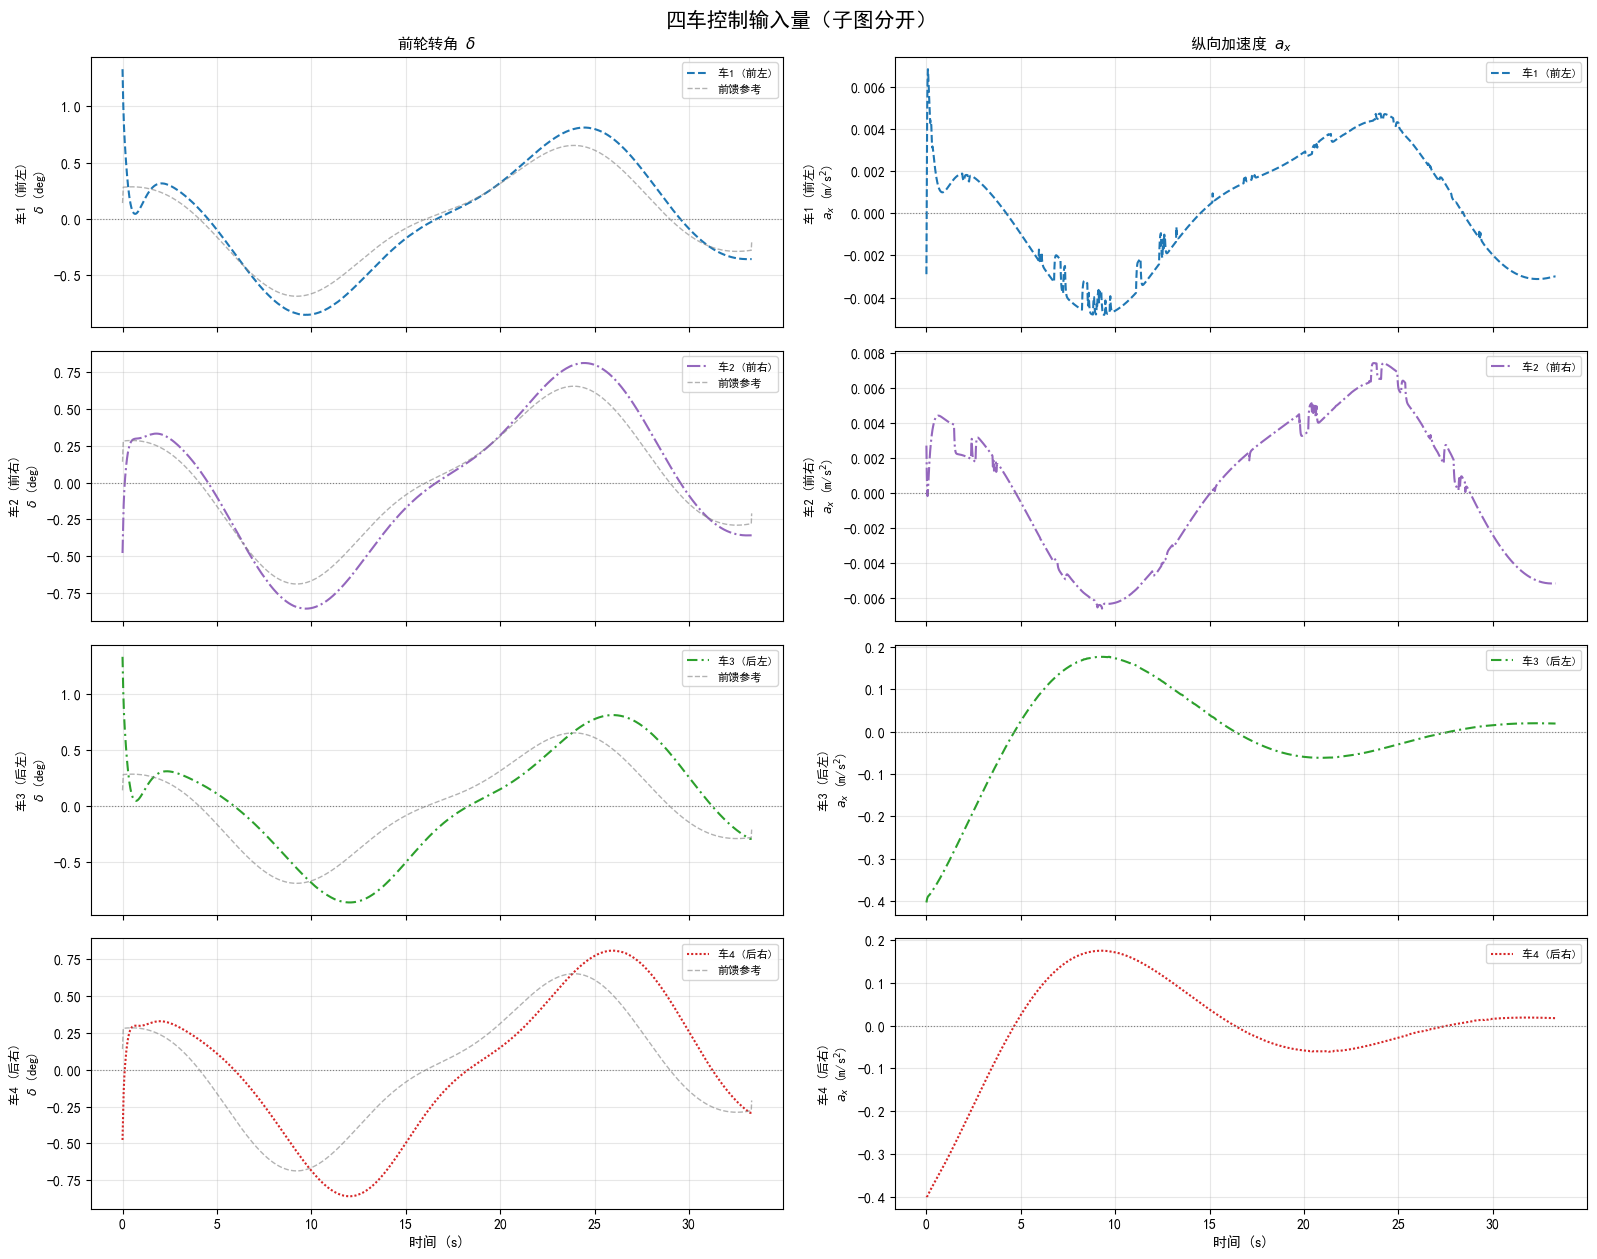

✅ 子图分开版已保存：inputs_separated.png


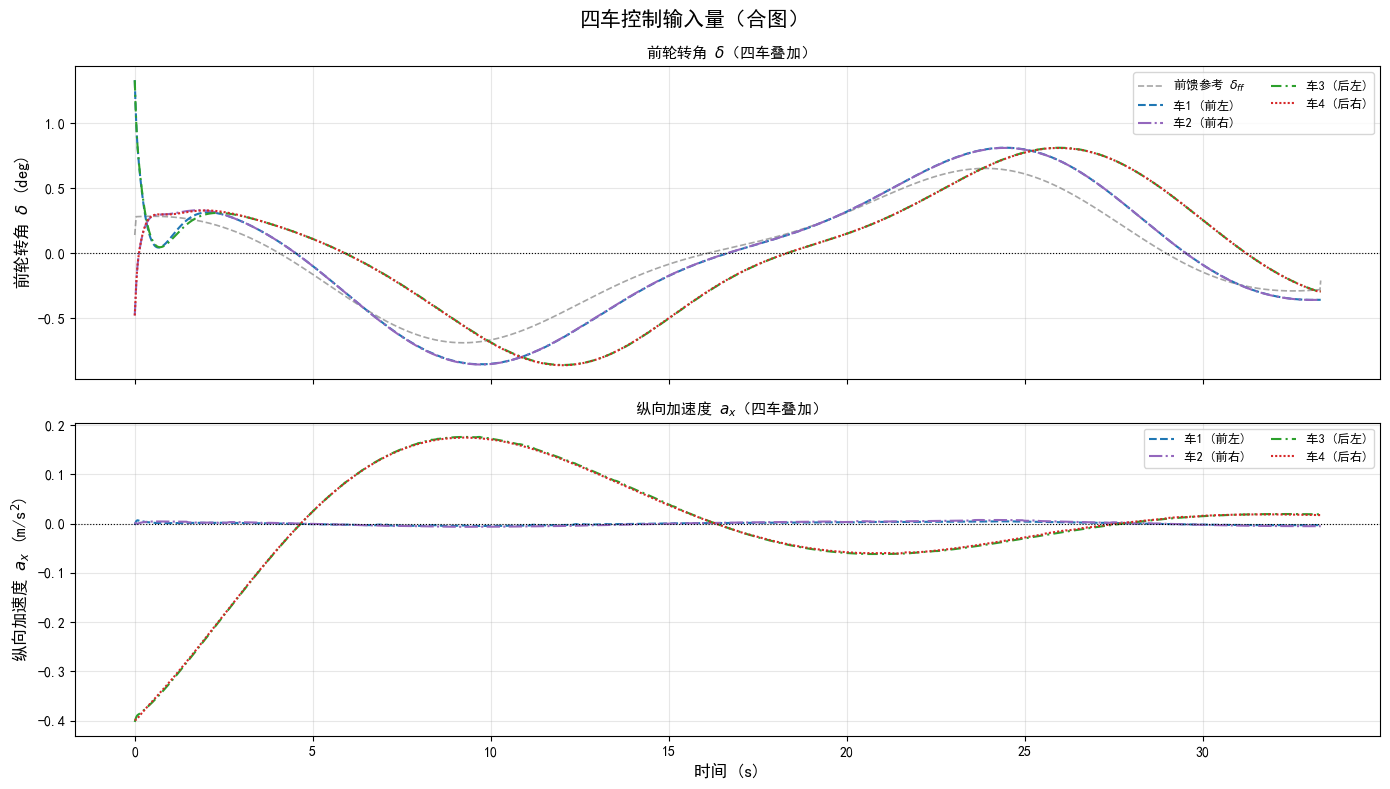

✅ 合图版已保存：inputs_combined.png


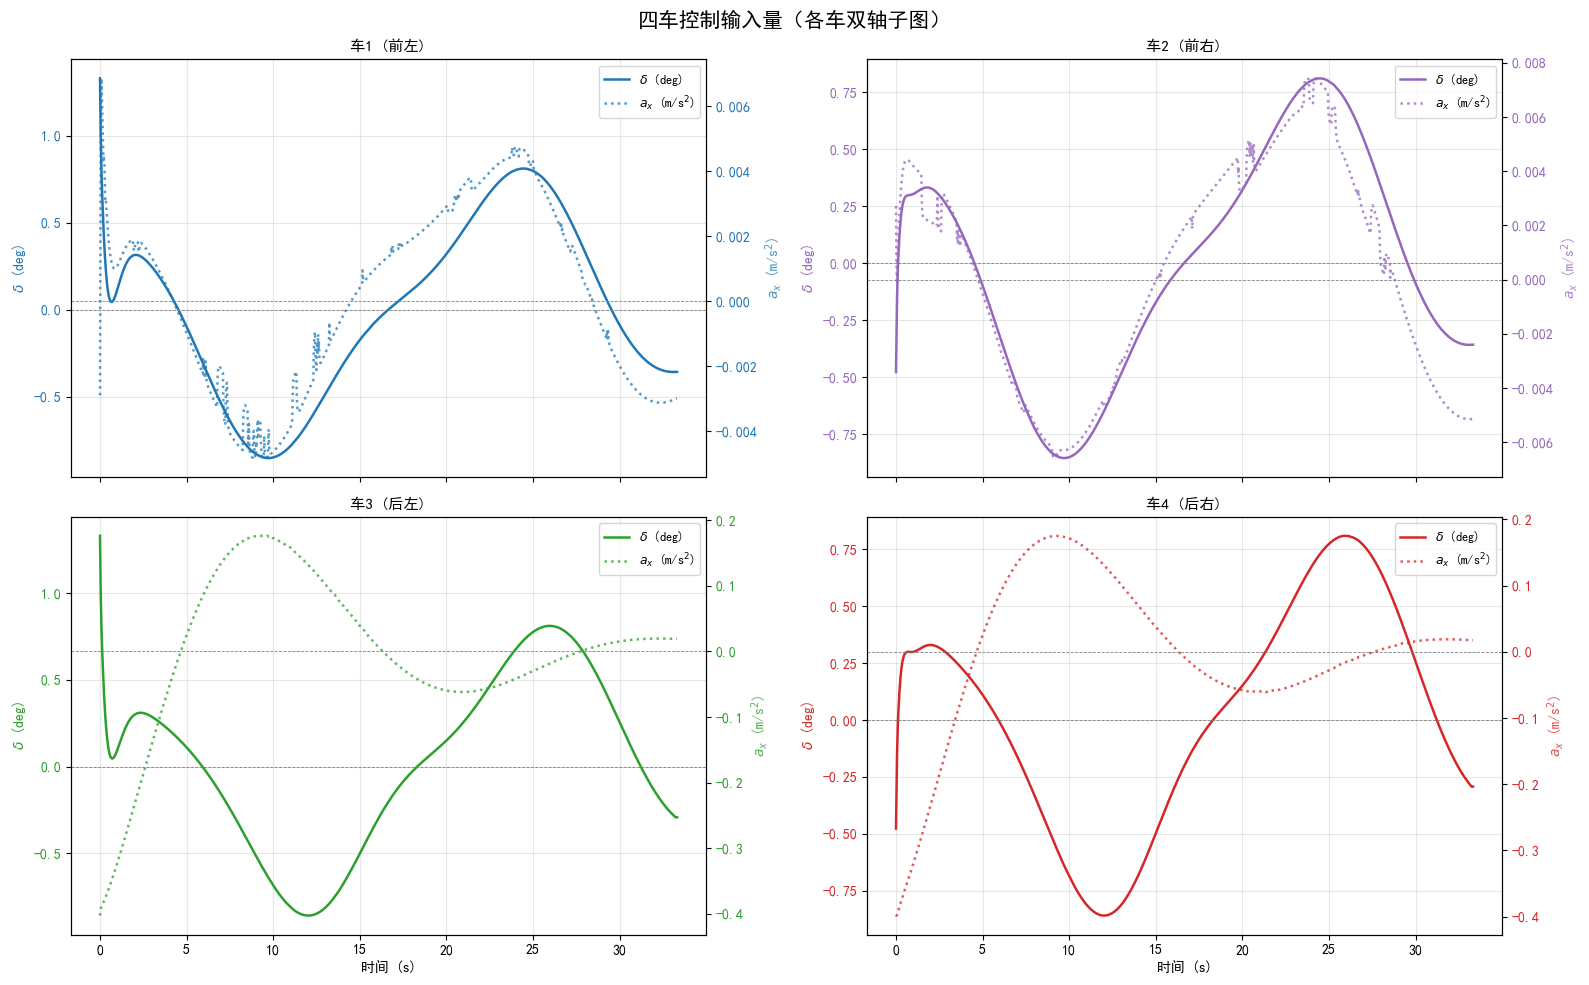

✅ 双轴子图版已保存：inputs_dual_axis.png


In [34]:
# =========================
# Plotting - 四车协同路径跟踪（四车不同线条版）
# =========================
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5, color='black')

# 四车不同线条样式（颜色 + 线型组合，更易区分）
styles = [
    {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'linewidth': 1.8, 'label': '车3 (后左)'},
    {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'linewidth': 1.8, 'label': '车4 (后右)'}
]

for v in range(num_vehicles):
    # 更鲁棒的有效长度判断：允许少量非有限值，只取最后一个有效索引
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                           for idx in range(traj_length)])

    if not np.any(valid_mask):
        print(f"⚠️ 车{v + 1} 全部状态无效，无轨迹可画")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    # 提取有效数据
    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 保护：裁剪s范围，避免插值越界
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet转全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 使用不同线条样式绘制
    plt.plot(x_v, y_v,
             color=styles[v]['color'],
             linestyle=styles[v]['linestyle'],
             linewidth=styles[v]['linewidth'],
             label=styles[v]['label'])

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车协同搬运路径跟踪 (Double Lane Change)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# ====================== 额外诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                      for idx in range(traj_length))
    last_valid_s = xt_actual_vehicles[v][valid_count - 1, 0] if valid_count > 0 else "N/A"
    print(f"车{v + 1} → 有效步数: {valid_count}/{traj_length} | 最终s位置: {last_valid_s:.2f} m")
# =========================
# Plotting - 四车协同路径跟踪（四子图版）
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

styles = [
    {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'markevery': 30, 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'markevery': 30, 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'markevery': 30, 'linewidth': 1.8,
     'label': '车3 (后左)'},
    {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'markevery': 30, 'linewidth': 1.8,
     'label': '车4 (后右)'}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()  # 变成 [ax0, ax1, ax2, ax3]，方便用索引访问

for v in range(num_vehicles):
    ax = axes[v]

    # 画参考路径（每个子图都画）
    ax.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5,
            color='black', linestyle='-')

    # 有效长度判断
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                           for idx in range(traj_length)])

    if not np.any(valid_mask):
        ax.set_title(f"车{v + 1} - 全部状态无效")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 裁剪 s 范围
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet → 全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 画该车轨迹
    ax.plot(x_v, y_v,
            color=styles[v]['color'],
            linestyle=styles[v]['linestyle'],
            marker=styles[v]['marker'],
            markevery=styles[v]['markevery'],
            linewidth=styles[v]['linewidth'],
            label=styles[v]['label'])

    ax.set_title(f"{styles[v]['label']} 路径跟踪")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.6)

fig.suptitle("四车协同搬运路径跟踪 (Double Lane Change)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ====================== 诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                      for idx in range(traj_length))
    last_valid_s = xt_actual_vehicles[v][valid_count - 1, 0] if valid_count > 0 else "N/A"
    print(f"车{v + 1} → 有效步数: {valid_count}/{traj_length} | 最终s位置: {last_valid_s:.2f} m")
# =========================
# 输入量绘图：前轮转角 & 纵向加速度 (修复字体警告版)
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ── 时间轴 ────────────────────────────────────────────────
# u_vehicles[v] shape: (traj_length-1, 2)
N_ctrl = u_vehicles[0].shape[0]  # = traj_length - 1
t_ctrl = np.arange(N_ctrl) * dt  # 单位：秒

# ── 颜色 / 标签 ───────────────────────────────────────────
colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
ls_v = ['--', '-.', (0, (5, 2, 1, 2)), (0, (1, 1))]

# =========================================================
# 图1：子图分开
# =========================================================
fig1, axes1 = plt.subplots(
    nrows=num_vehicles, ncols=2,
    figsize=(16, 3.2 * num_vehicles),
    sharex=True
)
fig1.suptitle('四车控制输入量（子图分开）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]  # 前轮转角 (rad)
    ax_v = u_vehicles[v][:, 1]  # 纵向加速度 (m/s^2)

    # ── 左列：前轮转角 ─────────────────────────────────
    ax_left = axes1[v, 0]
    ax_left.plot(t_ctrl, np.rad2deg(delta_v),
                 color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                 label=labels_v[v])
    ax_left.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    # 画前馈量（纯参考，供对比）
    delta_ff_ref = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[:N_ctrl]
    ax_left.plot(t_ctrl, np.rad2deg(delta_ff_ref),
                 color='gray', linewidth=1.0, linestyle='--',
                 alpha=0.6, label='前馈参考')

    ax_left.set_ylabel(f"{labels_v[v]}\n$\\delta$ (deg)", fontsize=9)
    ax_left.legend(fontsize=8, loc='upper right')
    ax_left.grid(True, alpha=0.3)

    if v == 0:
        ax_left.set_title('前轮转角 $\\delta$', fontsize=11)
    if v == num_vehicles - 1:
        ax_left.set_xlabel('时间 (s)', fontsize=10)

    # ── 右列：纵向加速度 ───────────────────────────────
    ax_right = axes1[v, 1]
    ax_right.plot(t_ctrl, ax_v,
                  color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                  label=labels_v[v])
    ax_right.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    ax_right.set_ylabel(f"{labels_v[v]}\n$a_x$ (m/s$^2$)", fontsize=9)
    ax_right.legend(fontsize=8, loc='upper right')
    ax_right.grid(True, alpha=0.3)

    if v == 0:
        ax_right.set_title('纵向加速度 $a_x$', fontsize=11)
    if v == num_vehicles - 1:
        ax_right.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_separated.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 子图分开版已保存：inputs_separated.png")

# =========================================================
# 图2：合图
# =========================================================
fig2, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(14, 8),
    sharex=True
)
fig2.suptitle('四车控制输入量（合图）', fontsize=15, fontweight='bold')

# ── 上图：前轮转角 ─────────────────────────────────────
delta_ff_ref = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[:N_ctrl]
ax_top.plot(t_ctrl, np.rad2deg(delta_ff_ref),
            color='gray', linewidth=1.2, linestyle='--',
            alpha=0.7, label='前馈参考 $\\delta_{ff}$')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]
    ax_top.plot(t_ctrl, np.rad2deg(delta_v),
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_top.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_top.set_ylabel('前轮转角 $\\delta$ (deg)', fontsize=12)
ax_top.legend(loc='upper right', fontsize=9, ncol=2)
ax_top.grid(True, alpha=0.3)
ax_top.set_title('前轮转角 $\\delta$（四车叠加）', fontsize=11)

# ── 下图：纵向加速度 ───────────────────────────────────
for v in range(num_vehicles):
    ax_v = u_vehicles[v][:, 1]
    ax_bot.plot(t_ctrl, ax_v,
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_bot.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_bot.set_ylabel('纵向加速度 $a_x$ (m/s$^2$)', fontsize=12)
ax_bot.set_xlabel('时间 (s)', fontsize=12)
ax_bot.legend(loc='upper right', fontsize=9, ncol=2)
ax_bot.grid(True, alpha=0.3)
ax_bot.set_title('纵向加速度 $a_x$（四车叠加）', fontsize=11)

plt.tight_layout()
plt.savefig('inputs_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 合图版已保存：inputs_combined.png")

# =========================================================
# 图3：四子图版（每辆车一个子图，delta + ax 双轴）
# =========================================================
fig3, axes3 = plt.subplots(
    nrows=2, ncols=2,
    figsize=(16, 10),
    sharex=True
)
axes3 = axes3.flatten()
fig3.suptitle('四车控制输入量（各车双轴子图）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    ax_l = axes3[v]  # 左轴（转角）
    ax_r = ax_l.twinx()  # 右轴（加速度）

    delta_v = np.rad2deg(u_vehicles[v][:, 0])
    accel_v = u_vehicles[v][:, 1]

    l1, = ax_l.plot(t_ctrl, delta_v,
                    color=colors_v[v], linestyle='-', linewidth=1.8,
                    label='$\\delta$ (deg)')
    l2, = ax_r.plot(t_ctrl, accel_v,
                    color=colors_v[v], linestyle=':', linewidth=1.8,
                    alpha=0.75, label='$a_x$ (m/s$^2$)')

    ax_l.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax_r.axhline(0, color='gray', linewidth=0.6, linestyle='--')

    ax_l.set_ylabel('$\\delta$ (deg)', fontsize=10, color=colors_v[v])
    ax_r.set_ylabel('$a_x$ (m/s$^2$)', fontsize=10, color=colors_v[v], alpha=0.8)
    ax_l.tick_params(axis='y', labelcolor=colors_v[v])
    ax_r.tick_params(axis='y', labelcolor=colors_v[v])

    ax_l.set_title(labels_v[v], fontsize=11)
    ax_l.grid(True, alpha=0.3)

    lines = [l1, l2]
    labels_leg = [l.get_label() for l in lines]
    ax_l.legend(lines, labels_leg, loc='upper right', fontsize=9)

    if v >= 2:
        ax_l.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 双轴子图版已保存：inputs_dual_axis.png")

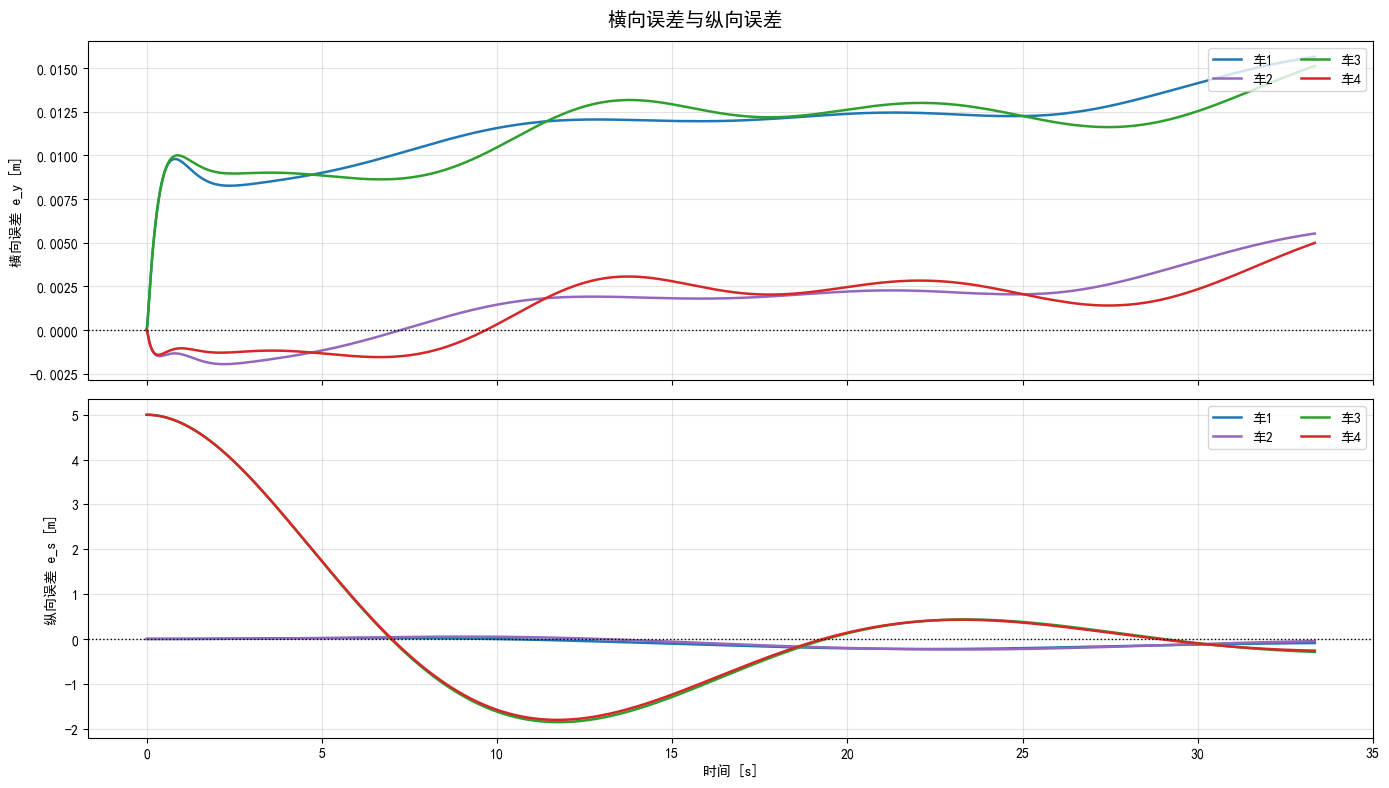

=== 误差统计 ===
车1: RMSE(e_y)=0.0119 m, Max|e_y|=0.0157 m | RMSE(e_s)=0.1316 m, Max|e_s|=0.2254 m
车2: RMSE(e_y)=0.0024 m, Max|e_y|=0.0055 m | RMSE(e_s)=0.1291 m, Max|e_s|=0.2355 m
车3: RMSE(e_y)=0.0116 m, Max|e_y|=0.0151 m | RMSE(e_s)=1.7242 m, Max|e_s|=5.0000 m
车4: RMSE(e_y)=0.0022 m, Max|e_y|=0.0050 m | RMSE(e_s)=1.7126 m, Max|e_s|=5.0000 m


In [35]:
# =========================
# 横向误差 & 纵向误差绘图
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

t_eval = t_ref[:traj_length]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('横向误差与纵向误差', fontsize=14, fontweight='bold')

colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1', '车2', '车3', '车4']

err_stats = []

for v in range(num_vehicles):
    x_hist = xt_actual_vehicles[v]

    # 每辆车的参考（与闭环中构造 x_ref_raw_v 的逻辑一致）
    s_ref_v = x_ref_raw[0, :] + x0_vehicles[v][0]
    ey_ref_v = np.full(traj_length, x0_vehicles[v][1])

    e_long = x_hist[:, 0] - s_ref_v          # 纵向误差 e_s
    e_lat = x_hist[:, 1] - ey_ref_v           # 横向误差 e_y

    valid = np.isfinite(e_long) & np.isfinite(e_lat)
    if not np.any(valid):
        print(f"车{v+1}: 无有效误差数据")
        continue

    c = colors_v[v % len(colors_v)]
    label = labels_v[v] if v < len(labels_v) else f'车{v+1}'

    ax1.plot(t_eval[valid], e_lat[valid], color=c, linewidth=1.8, label=label)
    ax2.plot(t_eval[valid], e_long[valid], color=c, linewidth=1.8, label=label)

    rmse_lat = float(np.sqrt(np.mean(e_lat[valid] ** 2)))
    rmse_long = float(np.sqrt(np.mean(e_long[valid] ** 2)))
    max_lat = float(np.max(np.abs(e_lat[valid])))
    max_long = float(np.max(np.abs(e_long[valid])))

    err_stats.append((v + 1, rmse_lat, max_lat, rmse_long, max_long))

ax1.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
ax2.axhline(0.0, color='black', linestyle=':', linewidth=1.0)

ax1.set_ylabel('横向误差 e_y [m]')
ax2.set_ylabel('纵向误差 e_s [m]')
ax2.set_xlabel('时间 [s]')

ax1.grid(True, alpha=0.35)
ax2.grid(True, alpha=0.35)
ax1.legend(loc='upper right', ncol=min(2, num_vehicles))
ax2.legend(loc='upper right', ncol=min(2, num_vehicles))

plt.tight_layout()
plt.show()

print("=== 误差统计 ===")
for vid, rmse_lat, max_lat, rmse_long, max_long in err_stats:
    print(
        f"车{vid}: "
        f"RMSE(e_y)={rmse_lat:.4f} m, Max|e_y|={max_lat:.4f} m | "
        f"RMSE(e_s)={rmse_long:.4f} m, Max|e_s|={max_long:.4f} m"
    )
